## Материалы:
* [Презентация](https://disk.yandex.ru/i/OKMKVEsqIIGo0w)

<div style="border: ridge lightgreen 2px; padding: 20px">
    
# Поиск клиента с неоптимальными тарифами телеком-провайдера "НуПозвони".

**Суть проекта:** мы - аналитики телеком-провайдера «НуПозвони»! Наши клиенты − колл-центры, мы хотим проанализировать наши тарифы, понять, насколько они подходят нашим клиентам и насколько для наших клиентов будет выгодна смена тарифа.

**Задача проекта:** найти клиентов, которые переплачивают на текущих тарифах.

В ходе исследования мы будем использовать следующие правила формирования тарифов:

| Ежемесячная плата за тариф: | Дополнительная ежемесячная плата за каждого оператора: |
|----------|-------|
| Тариф А — 4000 ₽, | Тариф А — 50 ₽, |
| Тариф B — 2000 ₽, | Тариф B — 150 ₽, |
| Тариф С — 1000 ₽. | Тариф С — 300 ₽. |

**Входящие и внутренние звонки — бесплатны на всех тарифах.**

| Исходящие звонки внутри сети, включённые в тариф: | Цена сверх лимита: | Исходящие звонки, кроме внутренних: |
|----------|-------|--------|
| Тариф А — 2000 минут, | A — 0.1 ₽/мин., | A — 0.3 ₽/мин., |
| Тариф B — 500 минут, | B — 0.15 ₽/мин., | B — 0.5 ₽/мин., |
| Тариф С — нет. | C — 0.3 ₽/мин. | C — 0.7 ₽/мин. |

---

**Описание данных:**

Датасет: `/datasets/telecom_dataset.csv`

- `user_id` — идентификатор клиента;
- `date` — дата статистики;
- `direction` — направление вызовов: `out` — исходящий вызов, `in` — входящий;
- `internal` — маркер внутренних и внешних вызовов;
- `operator_id` — идентификатор оператора;
- `is_missed_call` — маркер пропущенных вызовов;
- `calls_count` — количество звонков;
- `call_duration` — длительность звонка без учёта времени ожидания, мин.;
- `total_call_duration` — длительность звонка с учётом времени ожидания, мин.

Датасет: `/datasets/telecom_clients.csv`

- `user_id` — идентификатор клиента;
- `tariff_plan` — тарифный план клиента;
- `date_start` — дата регистрации клиента в сервисе.

---   

**Ход исследования**
    
Данные получим из файлов: `telecom_dataset.csv` и `telecom_clients.csv`. О качестве датасетов информации нет. Перед тем как приступать к цели исследования, нам необходимо изучить данные.
    
Проверим данные на предмет ошибок и оценим их влияние на результаты исследования. В процессе преодобработки данных попробуем исправить все ошибки, которые могут привести к искажению конечного результата. Далее мы проведем исследовательский анализ данных, проверим гипотезы и напишем общий вывод.
    
Таким образом, исследование пройдет в следующие этапы:
    
- Загрузка и предобработка данных.
- Подготовка данных к исследованию.
- Исследовательский анализ данных.
- Выявление клиентов с неоптимальными тарифами
- Проверка гипотез.
- Написание общих выводов и рекомендаций.

# Шаг 1. Открытие файлов с данными и изучение общей информации о датасетах

Импортируем необходимые нам библиотеки для анализа данных:

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import mannwhitneyu

import warnings
warnings.filterwarnings('ignore')

### 1.1. Считаем CSV-файлы с данными с помощью библиотеки pandas и сохраним их в датафреймы

In [12]:
try:
    calls_data = pd.read_csv('https://code.s3.yandex.net/datasets/telecom_dataset.csv')
except:
    calls_data = pd.read_csv('C:/Users/etols/Downloads/telecom_dataset.csv')

In [13]:
try:
    clients = pd.read_csv('https://code.s3.yandex.net/datasets/telecom_clients.csv')
except:
    clients = pd.read_csv('C:/Users/etols/Downloads/telecom_clients.csv')

### 1.2. Изучение общей информации о датасетах

Напишем функцию для изучения общей информации данных с помощью методов `.info()`, `.head()`, `.describe()` и проверим данные на наличие пропусков и дубликатов:

In [17]:
def review(data):
    print(data.info())
    print('--------------------')
    display(data.head())
    print('--------------------')
    display(data.describe())
    print('--------------------')
    print('Пропусков в данных:')
    print(data.isna().sum())
    print('--------------------')
    print('Дубликатов в данных:', data.duplicated().sum())

In [18]:
review(calls_data)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53902 entries, 0 to 53901
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              53902 non-null  int64  
 1   date                 53902 non-null  object 
 2   direction            53902 non-null  object 
 3   internal             53785 non-null  object 
 4   operator_id          45730 non-null  float64
 5   is_missed_call       53902 non-null  bool   
 6   calls_count          53902 non-null  int64  
 7   call_duration        53902 non-null  int64  
 8   total_call_duration  53902 non-null  int64  
dtypes: bool(1), float64(1), int64(4), object(3)
memory usage: 3.3+ MB
None
--------------------


,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
0,166377,2019-08-04 00:00:00+03:00,in,False,NaN,True,2,0,4
1,166377,2019-08-05 00:00:00+03:00,out,True,880022.0,True,3,0,5
2,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,True,1,0,1
3,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,False,1,10,18
4,166377,2019-08-05 00:00:00+03:00,out,False,880022.0,True,3,0,25


--------------------


,user_id,operator_id,calls_count,call_duration,total_call_duration
count,53902.000000,45730.000000,53902.000000,53902.000000,53902.000000
mean,167295.344477,916535.993002,16.451245,866.684427,1157.133297
std,598.883775,21254.123136,62.917170,3731.791202,4403.468763
min,166377.000000,879896.000000,1.000000,0.000000,0.000000
25%,166782.000000,900788.000000,1.000000,0.000000,47.000000
50%,167162.000000,913938.000000,4.000000,38.000000,210.000000
75%,167819.000000,937708.000000,12.000000,572.000000,902.000000
max,168606.000000,973286.000000,4817.000000,144395.000000,166155.000000


--------------------
Пропусков в данных:
user_id                   0
date                      0
direction                 0
internal                117
operator_id            8172
is_missed_call            0
calls_count               0
call_duration             0
total_call_duration       0
dtype: int64
--------------------
Дубликатов в данных: 4900


***Мы видим достаточно много пропусков в столбце `internal` - 117 пропущенных значений, на которые посмотрим немного подробнее позже, и в столбце `operator_id` - 8172, очень много пропусков, что логично, скорее всего все эти звонки просто не успели распределиться на операторов, потому что клиенты заканчивали звонок.***

***Также, в датасете 4900 явных дубликатов, которые возможно придется удалить, проверим позднее данные.***

In [21]:
review(clients)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   user_id      732 non-null    int64 
 1   tariff_plan  732 non-null    object
 2   date_start   732 non-null    object
dtypes: int64(1), object(2)
memory usage: 17.3+ KB
None
--------------------


,user_id,tariff_plan,date_start
0,166713,A,2019-08-15
1,166901,A,2019-08-23
2,168527,A,2019-10-29
3,167097,A,2019-09-01
4,168193,A,2019-10-16


--------------------


,user_id
count,732.000000
mean,167431.927596
std,633.810383
min,166373.000000
25%,166900.750000
50%,167432.000000
75%,167973.000000
max,168606.000000


--------------------
Пропусков в данных:
user_id        0
tariff_plan    0
date_start     0
dtype: int64
--------------------
Дубликатов в данных: 0


***Во втором датасете нет дубликатов и пропусков, здесь потребуется только привести столбец `date_start` к типу данных `datetime` для удобства работы с данными.***

<div style="border:solid Chocolate 2px; padding: 40px">
    
***ВЫВОДЫ по Шагу 1:***

**Импорт библиотек:**

Были загружены все необходимые библиотеки для анализа и обработки данных, включая инструменты для работы с таблицами, типами данных и визуализацией.

**Создание функции:**

Реализована функция, предназначенная для вывода сводной информации о структуре датасетов, что позволяет быстро получить представление о типах данных, наличии пропусков и других характеристиках.

**Потребность в изменении типов данных:**

В ходе первичного анализа установлено, что ряд столбцов требует приведение к более подходящим типам данных:

В первом датасете:

- `date`: преобразование из `object` в `datetime`;

- `internal`: преобразование из `object` в `bool`;

- `operator_id`: преобразование из `float64` в `int64`.

Во втором датасете:

- `date_start`: преобразование из `object` в `datetime`. Эти преобразования необходимы для удобства работы с данными.

**Анализ дубликатов:**

В первом датасете выявлено 4900 полных дубликатов строк, подлежащих удалению во избежание искажения аналитических результатов. Во втором датасете дубликатов не обнаружено.

**Обнаружение пропущенных значений:**

В первом датасете обнаружены пропуски в следующих столбцах: `internal` — 117 пропущенных значений, `operator_id` — 8172 пропуска. Эти пропуски требуют дальнейшей обработки: заполнения, удаления или интерпретации в зависимости от контекста и задач анализа.

# Шаг 2. Предобработка данных

### 2.1. Обработка дубликатов в данных

Посмотрим на дубликаты в первом датасете, сначала выведем на экран часть этих дубликатов, чтобы посмотреть, что это действительно не ошибка:

In [30]:
calls_data[calls_data.duplicated(keep=False)].head(15)

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
6,166377,2019-08-05 00:00:00+03:00,out,False,880020.0,True,8,0,50
8,166377,2019-08-05 00:00:00+03:00,out,False,880020.0,True,8,0,50
27,166377,2019-08-12 00:00:00+03:00,in,False,NaN,True,2,0,34
28,166377,2019-08-12 00:00:00+03:00,in,False,NaN,True,2,0,34
38,166377,2019-08-14 00:00:00+03:00,in,False,NaN,True,1,0,3
43,166377,2019-08-14 00:00:00+03:00,out,False,880026.0,False,10,1567,1654
44,166377,2019-08-14 00:00:00+03:00,out,False,880026.0,False,10,1567,1654
45,166377,2019-08-14 00:00:00+03:00,in,False,NaN,True,1,0,3
46,166377,2019-08-15 00:00:00+03:00,out,False,880026.0,False,11,1413,1473
51,166377,2019-08-15 00:00:00+03:00,out,False,880026.0,False,11,1413,1473


Похоже, что это действительно дубликаты, потому что дублирующие строки имеют полностью идентичные значения во всех колонках. Различается только номер строки (первая колонка), все остальные данные совпадают.

Удалим эти дубликаты:

In [33]:
calls_data.drop_duplicates(inplace=True)

In [34]:
calls_data.duplicated().sum()

0

***Проверили, что после удаления дубликатов не осталось. Дубли могли появиться при выгрузке и загрузке данных, либо если выгружались данные несколькими таблицами, неправильные объединения могли создавать дублирующие строки без должной обработки.***

### 2.2. Обработка пропущенных значений

Посмотрим еще раз на процент пропущенных значений подумаем, чем их можно заполнить:

In [40]:
round(calls_data.isna().mean()* 100, 2).sort_values(ascending=False)

operator_id            15.22
internal                0.22
user_id                 0.00
date                    0.00
direction               0.00
is_missed_call          0.00
calls_count             0.00
call_duration           0.00
total_call_duration     0.00
dtype: float64

Пропусков в столбце `internal` всего менее 1 % от общего количества. Можно заменить их на более часто встречающееся значение в данном столбце:

In [42]:
calls_data['internal'].value_counts()

internal
False    43239
True      5653
Name: count, dtype: int64

In [43]:
calls_data['internal'] = calls_data['internal'].fillna(False)

Сложнее дело обстоит с пропусками в столбце `operator_id`, их более 15 % от общего количества, просто так удалить без потери данных не получится. Соответственно пропуски необходимо заполнить другим значением, например, нулевым, поскольку тип данных в столбце у нас будет числовой.

In [48]:
calls_data['operator_id'].unique()

array([    nan, 880022., 880020., ..., 952916., 959118., 957922.])

Оператора с нулевым ИД у нас в датасете не представлено, поэтому можем спокойно заменить этим значением пропуски.

In [50]:
calls_data['operator_id'] = calls_data['operator_id'].fillna(0)

Выведем еще раз количество пропущенных значений, проверим, что пропусков не осталось:

In [55]:
calls_data.isna().sum()

user_id                0
date                   0
direction              0
internal               0
operator_id            0
is_missed_call         0
calls_count            0
call_duration          0
total_call_duration    0
dtype: int64

### 2.3. Преобразование типов данных

Преобразуем данные в следующих столбцах: `date` и `date_start` в тип `datetime`, `internal` в тип `bool`, `operator_id` в тип `int` для удобства работы с данными, некоторые столбцы не требуют размерности 64, поэтому проведем по таким столбцам даункаст:

In [58]:
calls_data['date'] = pd.to_datetime(calls_data['date'])
clients['date_start'] = pd.to_datetime(clients['date_start'])
calls_data['internal'] = calls_data['internal'].astype('bool')

In [59]:
calls_data['user_id'] = pd.to_numeric(calls_data['user_id'], downcast='integer')
calls_data['operator_id'] = pd.to_numeric(calls_data['operator_id'], downcast='integer')
calls_data['calls_count'] = pd.to_numeric(calls_data['calls_count'], downcast='integer')

Проверим изменение типов данных:

In [61]:
display(calls_data.dtypes)

user_id                                    int32
date                   datetime64[ns, UTC+03:00]
direction                                 object
internal                                    bool
operator_id                                int32
is_missed_call                              bool
calls_count                                int16
call_duration                              int64
total_call_duration                        int64
dtype: object

Попробуем для удобства привести тип данных в дату без указания времени, как во втором датасете:

In [65]:
calls_data['date'] = pd.to_datetime(calls_data['date'].dt.date)

In [66]:
calls_data.dtypes

user_id                         int32
date                   datetime64[ns]
direction                      object
internal                         bool
operator_id                     int32
is_missed_call                   bool
calls_count                     int16
call_duration                   int64
total_call_duration             int64
dtype: object

***Типы данных во всех необходимых столбцах изменены.***

Теперь посмотрим, за какой период представлены данные в нашем датасете с информацией о звонках:

In [69]:
display(calls_data['date'].min())
display(calls_data['date'].max())

Timestamp('2019-08-02 00:00:00')

Timestamp('2019-11-28 00:00:00')

***Данные представлены за 2019 год, с 08 февраля по 28 ноября.***

Поскольку в данных год у нас представлен только один, 2019, то столбец с годом добавлять нет смысла, а вот столбец с месяцем добавим в датасет `calls_data`:

In [73]:
calls_data['month_call'] = calls_data['date'].dt.month

In [74]:
calls_data.head()

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration,month_call
0,166377,2019-08-04,in,False,0,True,2,0,4,8
1,166377,2019-08-05,out,True,880022,True,3,0,5,8
2,166377,2019-08-05,out,True,880020,True,1,0,1,8
3,166377,2019-08-05,out,True,880020,False,1,10,18,8
4,166377,2019-08-05,out,False,880022,True,3,0,25,8


***Столбец с месяцем звонка добавлен.***

Посмотрим, насколько полно представлены данные за весь период. Посмотрим количество звонков по каждому дню и построим график:

In [77]:
daily_calls = calls_data.groupby(calls_data['date'])['calls_count'].sum().reset_index()
daily_calls.columns = ['date', 'total_calls']
daily_calls.sort_values(by='total_calls', ascending=False)

,date,total_calls
101,2019-11-11,18222
115,2019-11-25,17502
116,2019-11-26,16542
70,2019-10-11,15383
112,2019-11-22,15118
...,...,...
1,2019-08-03,29
0,2019-08-02,21
8,2019-08-10,12
2,2019-08-04,6


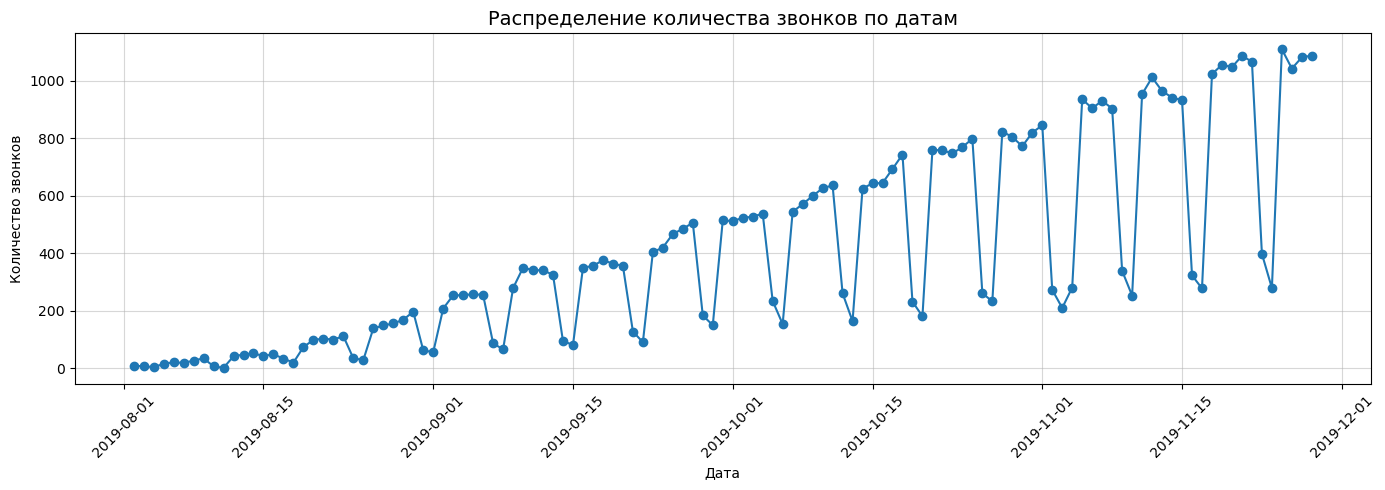

In [78]:
plt.figure(figsize=(14, 5))

calls_data.groupby(calls_data['date'].dt.date).size().plot(kind='line', marker='o', linestyle='-')
plt.title('Распределение количества звонков по датам', fontsize=14)
plt.xlabel('Дата', fontsize=10)
plt.ylabel('Количество звонков', fontsize=10)
plt.grid(True, alpha=.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Попробуем немного выправить данные за первый месяц данных представлено совсем немного, попробуем убрать его из анализа, и взять данные с того периода, где они представлены наиболее полно. Например, попробуем убрать данные августа:

In [82]:
daily_calls[daily_calls['date'] >= "2019-09-01"]

,date,total_calls
30,2019-09-01,587
31,2019-09-02,4191
32,2019-09-03,5106
33,2019-09-04,4296
34,2019-09-05,4144
...,...,...
114,2019-11-24,4099
115,2019-11-25,17502
116,2019-11-26,16542
117,2019-11-27,14790


Видно, что количество данных резко увеличилось со 2 сентября и далее только росло, можно как раз взять для анализа данный период, сформируем новый датафрейм для анализа, чтобы не перезаписывать данные в исходном:

In [84]:
calls_data_df = calls_data[calls_data['date'] > "2019-09-01"]
calls_data_df.head()

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration,month_call
118,166377,2019-09-02,in,False,880028,False,2,66,75,9
119,166377,2019-09-02,in,False,880026,False,1,31,34,9
120,166377,2019-09-02,out,False,880026,False,16,1853,1983,9
121,166377,2019-09-02,out,False,880026,True,6,0,168,9
122,166377,2019-09-02,out,False,880028,False,20,2529,2687,9


Как мы увидели выше, дней с нулевым количеством звонков в день в датасете не представлено. Однако посмотрим, все ли дни есть в датасете за указанный период, либо есть пропущенные дни:

In [86]:
calls_data_df['date'].unique()

<DatetimeArray>
['2019-09-02 00:00:00', '2019-09-03 00:00:00', '2019-09-04 00:00:00',
 '2019-09-05 00:00:00', '2019-09-06 00:00:00', '2019-09-09 00:00:00',
 '2019-09-10 00:00:00', '2019-09-11 00:00:00', '2019-09-12 00:00:00',
 '2019-09-13 00:00:00', '2019-09-16 00:00:00', '2019-09-17 00:00:00',
 '2019-09-18 00:00:00', '2019-09-19 00:00:00', '2019-09-20 00:00:00',
 '2019-09-23 00:00:00', '2019-09-24 00:00:00', '2019-09-25 00:00:00',
 '2019-09-26 00:00:00', '2019-09-27 00:00:00', '2019-09-30 00:00:00',
 '2019-10-01 00:00:00', '2019-10-02 00:00:00', '2019-10-03 00:00:00',
 '2019-10-04 00:00:00', '2019-10-07 00:00:00', '2019-10-08 00:00:00',
 '2019-10-09 00:00:00', '2019-10-10 00:00:00', '2019-10-11 00:00:00',
 '2019-10-14 00:00:00', '2019-10-15 00:00:00', '2019-10-16 00:00:00',
 '2019-10-17 00:00:00', '2019-10-18 00:00:00', '2019-10-19 00:00:00',
 '2019-10-20 00:00:00', '2019-10-21 00:00:00', '2019-10-22 00:00:00',
 '2019-10-23 00:00:00', '2019-10-24 00:00:00', '2019-10-25 00:00:00',
 '20

По данным наглядно видно, что есть пропущенные дни. Попробуем выяснить, почему так могло произойти. Вероятно, это просто будние дни и выходные, в которые операторы не работали. Добавим столбец с днем недели в датасет:

In [88]:
calls_data_df['day_call'] = calls_data_df['date'].dt.weekday

In [89]:
def day_type(x):
    if x == 5:
        return 'Выходной'
    if x == 6:
        return 'Выходной'
    else:
        return 'Будний день'
calls_data_df['day_type'] = calls_data_df['day_call'].apply(day_type)
calls_data_df.sample(5)

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration,month_call,day_call,day_type
8721,166658,2019-09-26,out,False,891158,False,2,688,714,9,3,Будний день
18686,166983,2019-09-05,out,False,901880,False,6,934,1030,9,3,Будний день
52582,168361,2019-11-13,out,False,945318,True,30,0,689,11,2,Будний день
48472,168187,2019-11-11,in,False,948286,False,14,822,1089,11,0,Будний день
1331,166405,2019-10-28,in,False,939474,False,3,356,400,10,0,Будний день


In [90]:
calls_data_df.groupby('day_type').agg({'calls_count': 'count'}).\
sort_values(by='calls_count').reset_index()

,day_type,calls_count
0,Выходной,4955
1,Будний день,42131


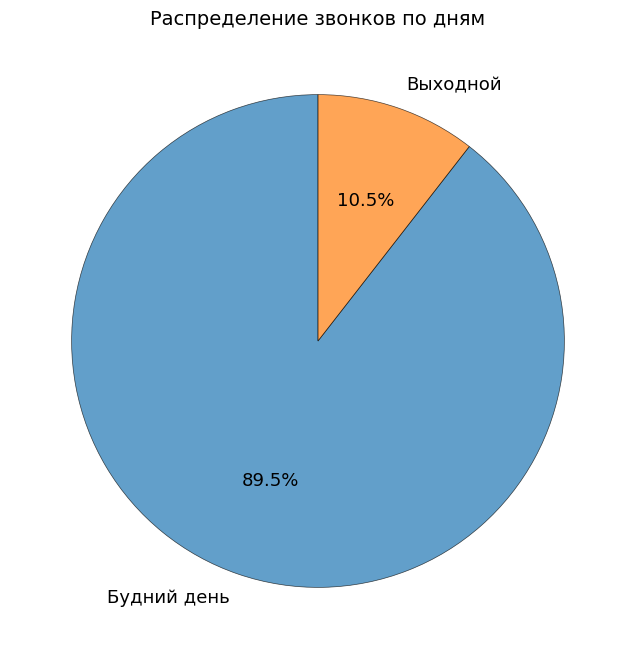

In [91]:
plt.figure(figsize=(16, 8))
wedge_props = {'alpha': .7, 'edgecolor': 'black', 'linewidth': .5}

calls_data_df['day_type'].value_counts(normalize=True).plot.pie(
    autopct='%1.1f%%',
    fontsize=13,
    startangle=90,
    ylabel='',
    wedgeprops=wedge_props
)
plt.title("Распределение звонков по дням", fontsize=14)
plt.show()

***В выходные дни тем не менее звонки есть, но их намного меньше. Что касается пропущенных дней с данными, возможно, данные выгружались вручную или системой с ошибками. В эти дни также могло не поступать ни одного звонка.***

### 2.4. Проверка на аномальные значения и выбросы

Посмотрим, есть ли отрицательные или нереально большие значения в `call_duration`, `calls_count`:

In [98]:
calls_data_df['call_duration'].describe()

count     47086.000000
mean        849.744637
std        3674.159457
min           0.000000
25%           0.000000
50%          40.000000
75%         574.000000
max      144395.000000
Name: call_duration, dtype: float64

In [99]:
calls_data_df['calls_count'].describe()

count    47086.000000
mean        16.326105
std         63.665202
min          1.000000
25%          1.000000
50%          4.000000
75%         12.000000
max       4817.000000
Name: calls_count, dtype: float64

***Отрицательных значений конечно в данных нет, однако не можем не обратить внимание на аномально большие значения в длительности разговора, максимальное значение - это 144 395 минут разговора (без учета ожидания клиента), или почти 2407 часов. Обычно стандартное время работы оператора контакт-центра - это 12 часов, и количество звонков одного оператора в день достигает 400 звонков.***

***Однако, есть информация - что id оператора - это рабочая учетная запись, а не id человека, то есть за одной рабочей учеткой может работать несколько человек одновременно. Поскольку нет возможности уточнить информацию, сколько операторов работает за конкретным рабочим местом, не думаю, что корректно будет убирать выбросы. Мы точно не уверены, выбросы ли это.***

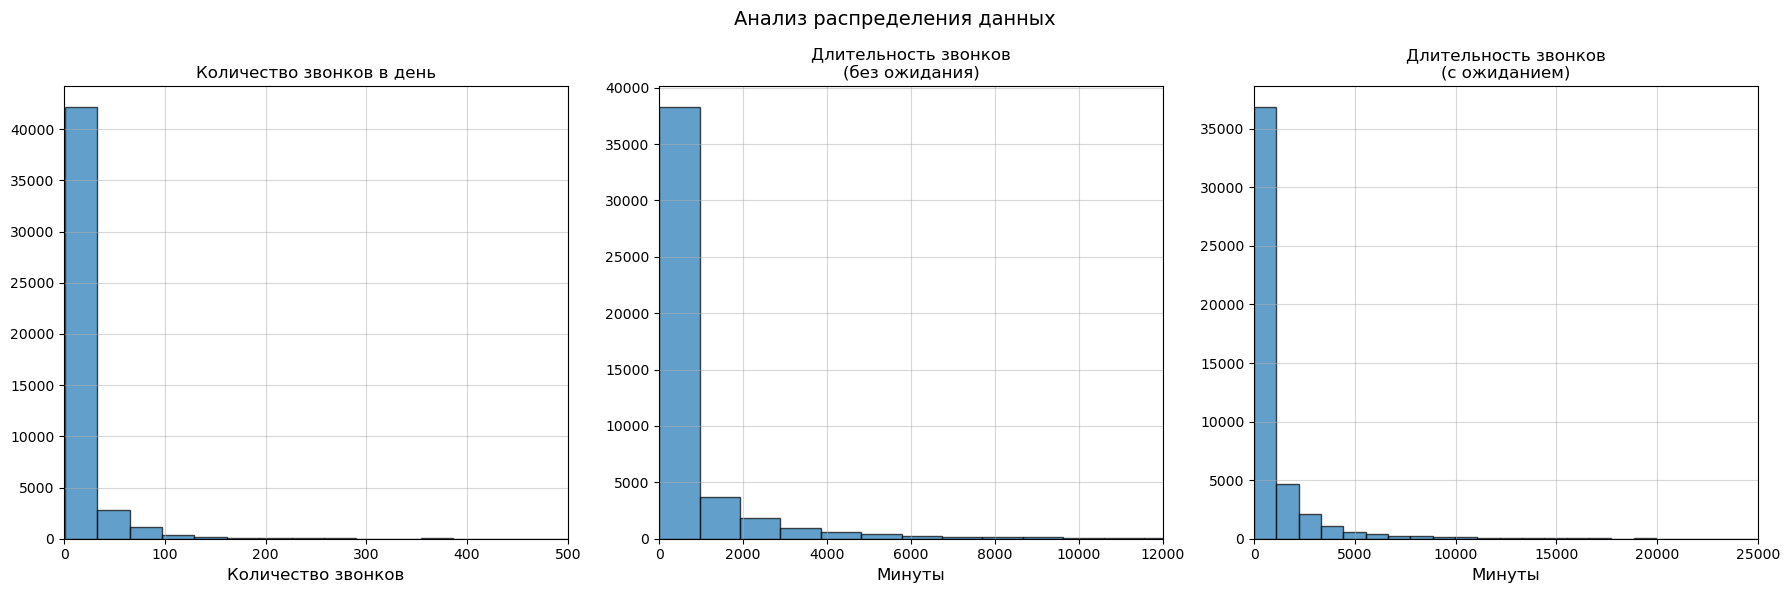

In [101]:
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.hist(calls_data_df['calls_count'], bins=150, edgecolor='black', alpha=.7)
plt.xlim(0, 500)
plt.title('Количество звонков в день', fontsize=12)
plt.xlabel('Количество звонков', fontsize=12)
plt.grid(alpha=.5)

plt.subplot(1, 3, 2)
plt.hist(calls_data_df['call_duration'], bins=150, edgecolor='black', alpha=.7)
plt.title('Длительность звонков\n(без ожидания)', fontsize=12)
plt.xlabel('Минуты', fontsize=12)
plt.xlim(0, 12000)
plt.grid(alpha=.5)

plt.subplot(1, 3, 3)
plt.hist(calls_data_df['total_call_duration'], bins=150, edgecolor='black', alpha=.7)
plt.title('Длительность звонков\n(с ожиданием)', fontsize=12)
plt.xlabel('Минуты', fontsize=12)
plt.xlim(0, 25000)
plt.grid(alpha=.5)

plt.suptitle('Анализ распределения данных', fontsize=14)

plt.tight_layout()
plt.show()

***Как мы видим, все-таки большинство значений датасета лежит в относительно небольшом диапазоне значений - количество звонков, большинство значений до 100 звонков в день, длительность звонков без ожидания клиента - большинство значений до 3000 минут, и длительность звонков с ожиданием клиента - большинство значений до 4000 минут.***

Посмотрим, у какого пользователя зафиксировано максимальное количество минут:

In [105]:
calls_data_df[calls_data_df['call_duration'] == 144395.000000]

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration,month_call,day_call,day_type
6946,166582,2019-09-25,out,False,885876,False,1230,144395,166155,9,2,Будний день


In [106]:
calls_data_df[calls_data_df['user_id'] == 166582]

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration,month_call,day_call,day_type
6739,166582,2019-09-02,out,False,885876,True,470,0,16145,9,0,Будний день
6740,166582,2019-09-02,in,False,885890,False,28,2189,2456,9,0,Будний день
6741,166582,2019-09-02,out,False,885890,True,305,0,10882,9,0,Будний день
6742,166582,2019-09-02,in,False,0,True,68,0,938,9,0,Будний день
6743,166582,2019-09-02,out,False,0,True,1,0,0,9,0,Будний день
...,...,...,...,...,...,...,...,...,...,...,...,...
7357,166582,2019-11-27,in,False,0,True,2,0,42,11,2,Будний день
7358,166582,2019-11-27,out,False,885876,True,21,0,776,11,2,Будний день
7359,166582,2019-11-28,in,False,0,True,7,0,89,11,3,Будний день
7360,166582,2019-11-28,out,False,885876,False,34,5357,5973,11,3,Будний день


Посмотрим у данного пользователя 166582 другие данные, их описательную статистику:

In [108]:
round(calls_data_df[calls_data_df['user_id'] == 166582].describe())

,user_id,date,operator_id,calls_count,call_duration,total_call_duration,month_call,day_call
count,565.0,565,565.0,565.0,565.0,565.0,565.0,565.0
mean,166582.0,2019-10-06 14:54:35.044247808,753078.0,216.0,12573.0,17462.0,10.0,3.0
min,166582.0,2019-09-02 00:00:00,0.0,1.0,0.0,0.0,9.0,0.0
25%,166582.0,2019-09-19 00:00:00,885876.0,13.0,0.0,536.0,9.0,1.0
50%,166582.0,2019-10-07 00:00:00,885876.0,55.0,2.0,2462.0,10.0,3.0
75%,166582.0,2019-10-21 00:00:00,885890.0,369.0,3354.0,16458.0,10.0,4.0
max,166582.0,2019-11-28 00:00:00,925922.0,1480.0,144395.0,166155.0,11.0,6.0
std,0.0,NaN,324019.0,287.0,26859.0,30514.0,1.0,2.0


***Как мы можем видеть из описательной статистики, очень сильно отличаются медиана от среднего значения в столбцах `call_duration`, `total_call_duration` и `calls_count`, что говорит о большом количестве выбросов в этих данных.***

Посмотрим далее на наличие времени разговора у звонков с меткой пропущенные:

In [112]:
calls_data_df[(calls_data_df['call_duration'] > 0) & (calls_data_df['is_missed_call'] == True)]

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration,month_call,day_call,day_type
1606,166405,2019-11-19,in,False,939478,True,1,165,173,11,1,Будний день
1635,166405,2019-11-21,in,False,882686,True,1,1,5,11,3,Будний день
1657,166405,2019-11-22,in,False,882686,True,1,1,5,11,4,Будний день
2283,166407,2019-09-23,in,False,888534,True,1,133,156,9,0,Будний день
2869,166482,2019-11-05,in,False,934074,True,1,1,15,11,1,Будний день
...,...,...,...,...,...,...,...,...,...,...,...,...
51599,168336,2019-11-01,in,False,947304,True,1,1,20,11,4,Будний день
51664,168336,2019-11-12,in,False,947304,True,1,69,72,11,1,Будний день
51693,168336,2019-11-15,in,False,947304,True,1,46,49,11,4,Будний день
51853,168336,2019-11-27,in,False,958416,True,1,40,65,11,2,Будний день


***Как мы видим, такие записи действительно есть, что является явной аномалией, потому что скорее всего звонок некорректно пометился, как пропущенный, с такими значениями мы бы обратились в технический отдел, от которого поступили данные. Здесь же, думаю, нужно удалить эти данные для дальнейшего исследования.***

Кстати, интересно посмотреть, какие пользователи присутствуют в таких некорректных записях. Может таких пользователей не так много, и мы можем на них обратить более пристальное внимание:

In [116]:
calls_data_df[(calls_data_df['call_duration'] > 0) & (calls_data_df['is_missed_call'] == True)]['user_id'].unique()

array([166405, 166407, 166482, 166485, 166503, 166511, 166536, 166541,
       166582, 166604, 166658, 166678, 166708, 166725, 166732, 166782,
       166837, 166896, 166916, 166939, 166946, 166974, 166983, 166997,
       167052, 167059, 167071, 167150, 167176, 167189, 167264, 167272,
       167445, 167466, 167497, 167545, 167551, 167580, 167626, 167650,
       167653, 167742, 167756, 167827, 167828, 167829, 167888, 167977,
       167994, 168041, 168062, 168091, 168154, 168187, 168252, 168264,
       168271, 168307, 168336, 168412])

Нет, слишком много разных пользователей, отдельно их исследовать не считаю необходимым. Однако, среди этих пользователей можно заметить нашего пользователя 166582 с максимально большим значением столбца `call_duration`. Удалим записи этого пользователя и удалим аномальные значения пропущенных звонков.

In [118]:
calls_data_df.drop(calls_data_df[calls_data_df['user_id'] == 166582].index, inplace=True)

In [120]:
calls_data_df.loc[(calls_data_df['call_duration'] > 0) & (calls_data_df['is_missed_call'] == True), 'is_missed_call'] = False

***Строки с отметками о НЕпропущенном звонке и нулевой длительностью звонка оставим в датасете, однако заменим в таких строках `is_missed_call` с `True` на `False` для последующего более корректного расчета затрат и выручки комипании.***

Плюс можно посмотреть, есть ли строки, в которых в столбце о пропущенном звонке есть отметка, что это действительно был НЕпропущенный звонок, но в столбце `operator_id` стоит отметка `0`, т.е. оператор не указан. Таких значений быть по идее не должно, потому что если есть длительность звонка, значит клиент с кем-то разговаривал, и это скорее всего является технической ошибкой.

In [126]:
calls_data_df[(calls_data_df['operator_id'] == 0) & (calls_data_df['is_missed_call'] == False)]

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration,month_call,day_call,day_type
704,166399,2019-09-02,in,False,0,False,1,68,115,9,0,Будний день
4089,166503,2019-09-26,out,False,0,False,1,213,220,9,3,Будний день
4136,166503,2019-10-09,in,False,0,False,1,374,405,10,2,Будний день
4198,166503,2019-10-21,out,True,0,False,2,382,397,10,0,Будний день
12752,166782,2019-09-03,in,False,0,False,3,229,277,9,1,Будний день
...,...,...,...,...,...,...,...,...,...,...,...,...
50930,168252,2019-11-28,in,True,0,False,2,265,274,11,3,Будний день
50946,168252,2019-11-28,in,False,0,False,45,23765,23897,11,3,Будний день
50955,168252,2019-11-28,out,False,0,False,22,11904,12211,11,3,Будний день
50956,168252,2019-11-28,out,True,0,False,1,159,168,11,3,Будний день


***Такие значения все же есть, но их немного, 112 штук, поскольку длительность звонка есть, и это впоследствии будет необходимо для расчета затрат и выручки, наличие данных значений отметим, но в датасете оставим.***

Посмотрим, сколько строк у нас осталось после очистки данных в датасете:

In [132]:
calls_data_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 46521 entries, 118 to 53901
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   user_id              46521 non-null  int32         
 1   date                 46521 non-null  datetime64[ns]
 2   direction            46521 non-null  object        
 3   internal             46521 non-null  bool          
 4   operator_id          46521 non-null  int32         
 5   is_missed_call       46521 non-null  bool          
 6   calls_count          46521 non-null  int16         
 7   call_duration        46521 non-null  int64         
 8   total_call_duration  46521 non-null  int64         
 9   month_call           46521 non-null  int32         
 10  day_call             46521 non-null  int32         
 11  day_type             46521 non-null  object        
dtypes: bool(2), datetime64[ns](1), int16(1), int32(4), int64(2), object(2)
memory usage: 3.0+ M

### 2.3. Подсчет количества уникальных клиентов, операторов

In [134]:
print('Количество уникальных клиентов, представленных в датасете:', calls_data['user_id'].nunique())
print('Количество уникальных рабочих мест для операторов, представленных в датасете:', calls_data['operator_id'].nunique())

Количество уникальных клиентов, представленных в датасете: 307
Количество уникальных рабочих мест для операторов, представленных в датасете: 1093


<div style="border:solid Chocolate 2px; padding: 40px">
    
***ВЫВОДЫ по Шагу 2:***

**Удаление дубликатов:**

Из исходного датасета были удалены явные дубликаты записей, что позволило избежать искажений при анализе частоты и длительности звонков.

**Обработка пропущенных значений:**

В столбце `internal` все пропущенные значения были устранены, что обеспечило корректную типизацию и дальнейшую работу с данными.

В столбце `operator_id` доля пропущенных значений составила более 15% от общего объема данных. Учитывая это, значения не были удалены, чтобы не потерять значимую часть выборки. Вместо этого пропуски были заменены на значение `0`, что может трактоваться как «отсутствие оператора» или «непривязанное рабочее место».

**Приведение данных к нужным типам:**

Столбцы `date` и `date_start` приведены к типу `datetime` для возможности временного анализа.

Столбец `internal` преобразован в тип `bool`, отражающий бинарную природу признака.

Столбец `operator_id` приведён к типу `int`, что обеспечивает корректную агрегацию и группировку данных.

**Обнаружение и устранение аномалий:**
    
Удалены данные с логами звонков августа, взят для дальнейшего анализа период со `2 сентября 2019 года`, поскольку за время первого месяца данные собирались очень плохо и могут несколько исказить результаты исследования.

Удалены записи, связанные с пользователем с ID `166582`, поскольку его показатели длительности звонков значительно выходили за рамки нормального распределения, что могло существенно исказить результаты анализа.

Также были исключены записи, содержащие логическую аномалию: звонки, отмеченные как пропущенные (`is_missed_call` == `True`), при этом имеющие ненулевую длительность, что не соответствует типичному поведению системы. А также звонки, отмеченные, НЕ как пропущенные (`is_missed_call` == `False`), при этом не распределившиеся на операторов.

После выполнения очистки и предобработки данных, финальный датасет содержит информацию о звонках 307 уникальных пользователей и 1093 оператора или рабочих места, что позволяет проводить дальнейший анализ с более высокой степенью достоверности.

# Шаг 3. EDA: общие показатели, поведение клиентов и анализ звонков

Сначала нам необходимо объединить датасеты в один и с помощью ранее определенной функции изучить общую информацию:

In [139]:
df = calls_data_df.merge(clients, on='user_id', how='inner')

In [140]:
review(df)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46521 entries, 0 to 46520
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   user_id              46521 non-null  int32         
 1   date                 46521 non-null  datetime64[ns]
 2   direction            46521 non-null  object        
 3   internal             46521 non-null  bool          
 4   operator_id          46521 non-null  int32         
 5   is_missed_call       46521 non-null  bool          
 6   calls_count          46521 non-null  int16         
 7   call_duration        46521 non-null  int64         
 8   total_call_duration  46521 non-null  int64         
 9   month_call           46521 non-null  int32         
 10  day_call             46521 non-null  int32         
 11  day_type             46521 non-null  object        
 12  tariff_plan          46521 non-null  object        
 13  date_start           46521 non-

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration,month_call,day_call,day_type,tariff_plan,date_start
0,166377,2019-09-02,in,False,880028,False,2,66,75,9,0,Будний день,B,2019-08-01
1,166377,2019-09-02,in,False,880026,False,1,31,34,9,0,Будний день,B,2019-08-01
2,166377,2019-09-02,out,False,880026,False,16,1853,1983,9,0,Будний день,B,2019-08-01
3,166377,2019-09-02,out,False,880026,True,6,0,168,9,0,Будний день,B,2019-08-01
4,166377,2019-09-02,out,False,880028,False,20,2529,2687,9,0,Будний день,B,2019-08-01


--------------------


,user_id,date,operator_id,calls_count,call_duration,total_call_duration,month_call,day_call,date_start
count,46521.000000,46521,46521.000000,46521.000000,46521.00000,46521.000000,46521.000000,46521.000000,46521
mean,167331.401690,2019-10-25 18:18:10.655832832,780547.323918,13.906386,707.36764,937.460394,10.287204,2.363836,2019-09-10 13:52:00.371444992
min,166377.000000,2019-09-02 00:00:00,0.000000,1.000000,0.00000,0.000000,9.000000,0.000000,2019-08-01 00:00:00
25%,166896.000000,2019-10-08 00:00:00,891414.000000,1.000000,0.00000,47.000000,10.000000,1.000000,2019-08-23 00:00:00
50%,167180.000000,2019-10-29 00:00:00,907502.000000,4.000000,40.00000,207.000000,10.000000,2.000000,2019-09-05 00:00:00
75%,167828.000000,2019-11-15 00:00:00,932292.000000,12.000000,566.00000,872.000000,11.000000,4.000000,2019-10-02 00:00:00
max,168606.000000,2019-11-28 00:00:00,973286.000000,4817.000000,41344.00000,58027.000000,11.000000,6.000000,2019-10-31 00:00:00
std,591.337258,NaN,327982.983415,51.172323,1796.52631,2105.616461,0.744248,1.684126,NaN


--------------------
Пропусков в данных:
user_id                0
date                   0
direction              0
internal               0
operator_id            0
is_missed_call         0
calls_count            0
call_duration          0
total_call_duration    0
month_call             0
day_call               0
day_type               0
tariff_plan            0
date_start             0
dtype: int64
--------------------
Дубликатов в данных: 0


***Видно, что после объединения данных потерь в строках не произошло, данные объединены полностью, т.е. для каждого клиента нашелся тариф, пропусков в данных не наблюдается.***

Посмотрим, на всякий случай, есть ли у нас клиенты, по которым информация о звонке присутствует еще до даты регистрации клиента:

In [143]:
df[df['date'] < df['date_start']]['user_id'].nunique()

0

***Некорректных записей о пользователях еще до даты их регистрации в телеком-компании нет.***

### 3.1. Подсчет количества клиентов на каждом тарифе + построение графика

In [149]:
df.groupby('tariff_plan')['user_id'].nunique()

tariff_plan
A     33
B    110
C    159
Name: user_id, dtype: int64

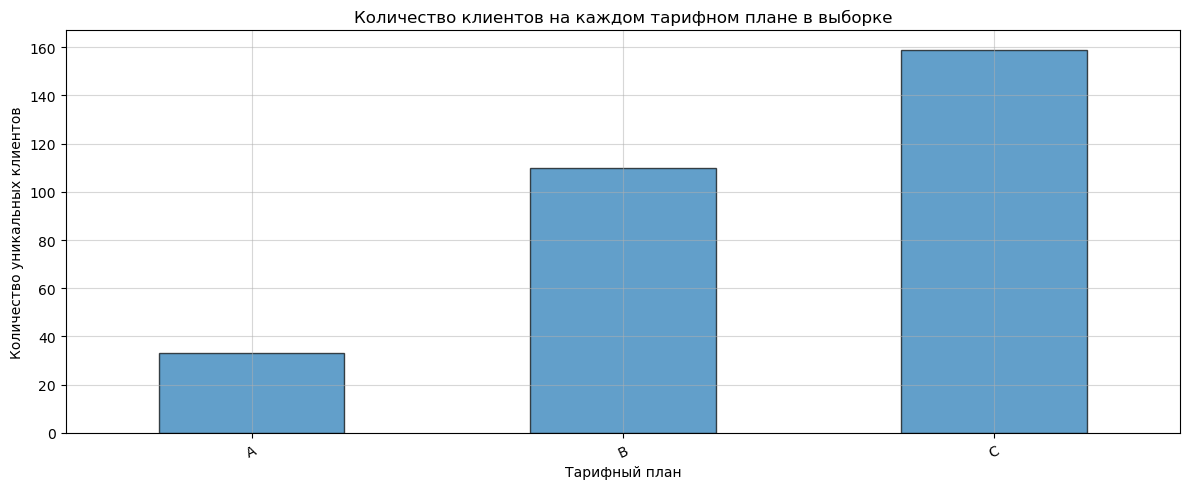

In [150]:
df.groupby('tariff_plan')['user_id'].nunique().plot(kind='bar', figsize=(12, 5), edgecolor='black', alpha=.7)

plt.title('Количество клиентов на каждом тарифном плане в выборке')
plt.xlabel('Тарифный план')
plt.ylabel('Количество уникальных клиентов')
plt.xticks(rotation=25)
plt.grid(alpha=.5)
plt.tight_layout()
plt.show()

***На тарифном плане с максимальной абонентской платой ожидаемо наблюдается меньшее количество клиентов — 33 клиента. Это соответствует типичной модели потребительского поведения, когда высокие фиксированные затраты сдерживают массовое подключение. В то же время, на двух других тарифах численность клиентов распределена практически равномерно: тариф B — 110 клиентов, тариф C — 159 клиентов, что указывает на схожую привлекательность данных предложений для пользователей.***

***Однако количественное распределение клиентов не позволяет в полной мере оценить оптимальность использования тарифов. Для более глубокого анализа необходимо дополнительно рассмотреть фактические расходы клиентов на звонки, это приблизит нас к цели нашего исследования - выявление тарифных планов, не оптимальных для клиентов, а также оценить потенциальные зоны для оптимизации расходов клиентов.***

Теперь посмотрим, сколько клиентов представлено в целом у компании по датасету `clients` и их распределение по тарифам, построим график:

In [156]:
print('Количество уникальных клиентов компании-заказчика:', clients['user_id'].nunique())

Количество уникальных клиентов компании-заказчика: 732


In [157]:
clients.groupby('tariff_plan')['user_id'].nunique()

tariff_plan
A     76
B    261
C    395
Name: user_id, dtype: int64

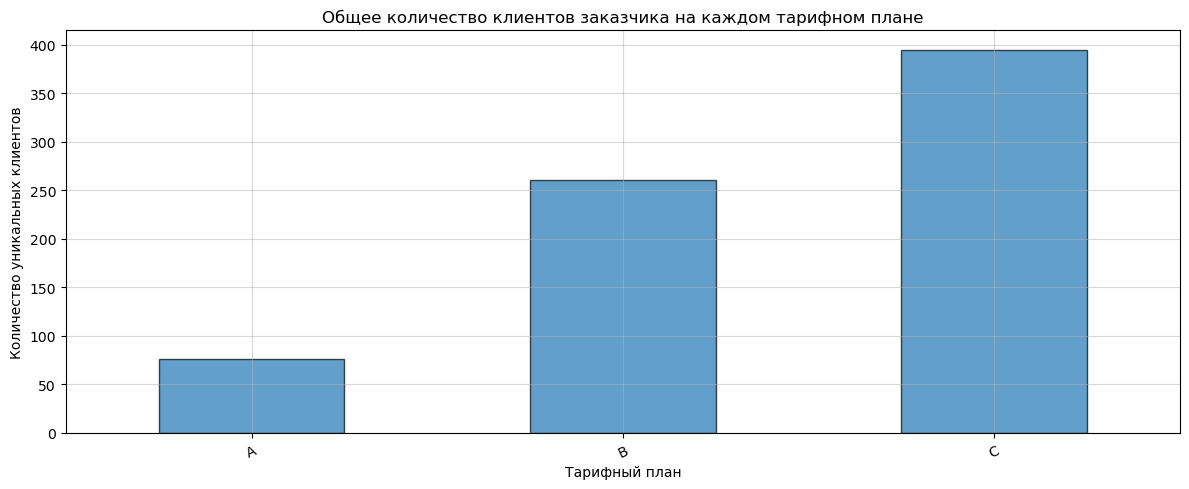

In [158]:
clients.groupby('tariff_plan')['user_id'].nunique().plot(kind='bar', figsize=(12, 5), edgecolor='black', alpha=.7)

plt.title('Общее количество клиентов заказчика на каждом тарифном плане')
plt.xlabel('Тарифный план')
plt.ylabel('Количество уникальных клиентов')
plt.xticks(rotation=25)
plt.grid(alpha=.5)
plt.tight_layout()
plt.show()

***Распределение по тарифам максимально близко к генеральной совокупности, что мы можем видеть и на графиках, столбцы почти совпадают, выборка репрезентативна.***

### 3.2. Анализ звонков

Проанализируем длительность звонков, построим распределение длительности звонков на разных тарифах на графике и посчитаем среднее/медианное значение в разрезе по тарифам:

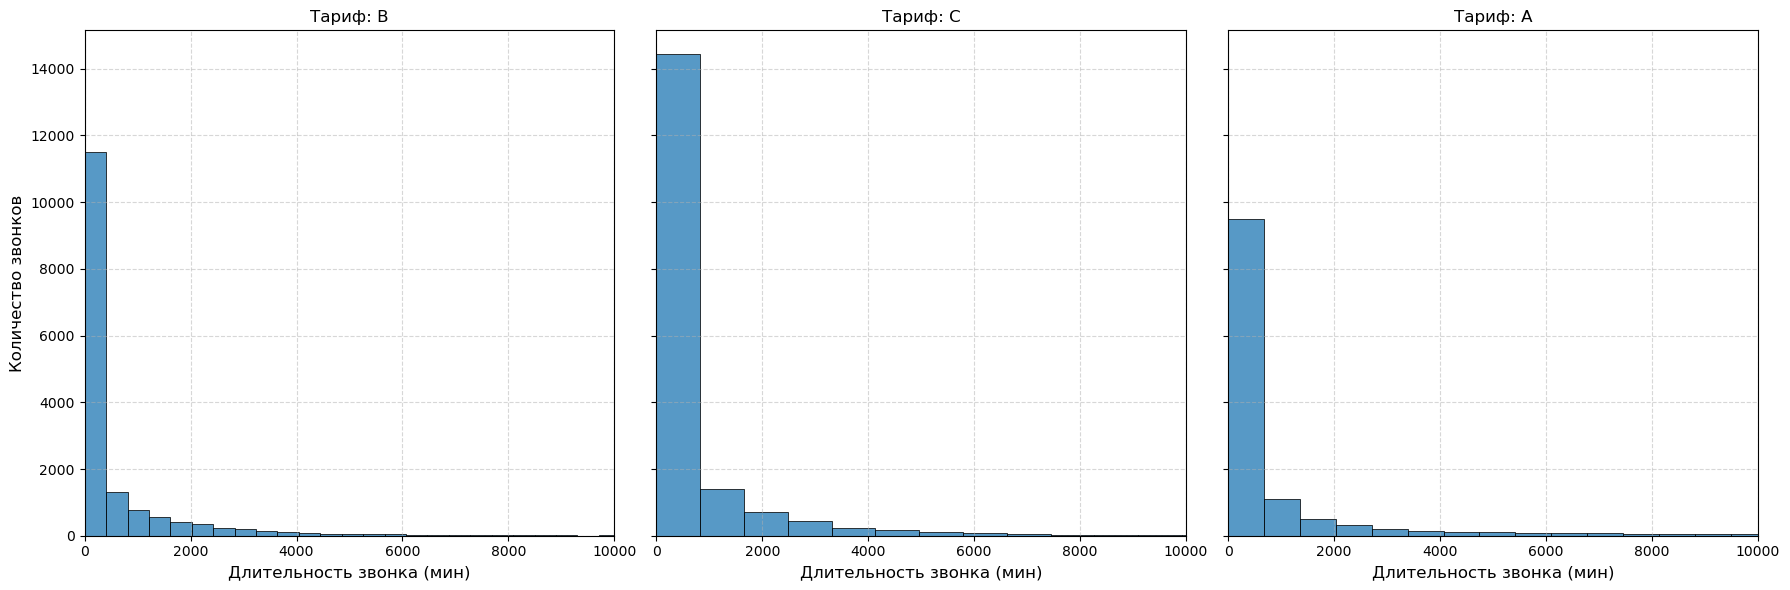

In [162]:
tariffs = df['tariff_plan'].unique()

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for i, tariff in enumerate(tariffs):
    sns.histplot(
        data=df[df['tariff_plan'] == tariff],
        x='call_duration',
        bins=50,
        ax=axes[i],
        edgecolor='black'
    )
    axes[i].set_title(f'Тариф: {tariff}', fontsize=12)
    axes[i].set_xlabel('Длительность звонка (мин)', fontsize=12)
    axes[i].set_xlim(0, 10000)
    axes[i].grid(linestyle='--', alpha=.5)

axes[0].set_ylabel('Количество звонков', fontsize=12)
plt.tight_layout()
plt.show()

***Распределение длительности звонков во всех трёх тарифных планах демонстрирует сильную правостороннюю асимметрию: большинство звонков укладываются в короткий временной интервал, но при этом есть небольшая доля звонков, которые длятся существенно дольше. Это характерно для телекоммуникационных данных и указывает на наличие редких, но очень продолжительных звонков.***

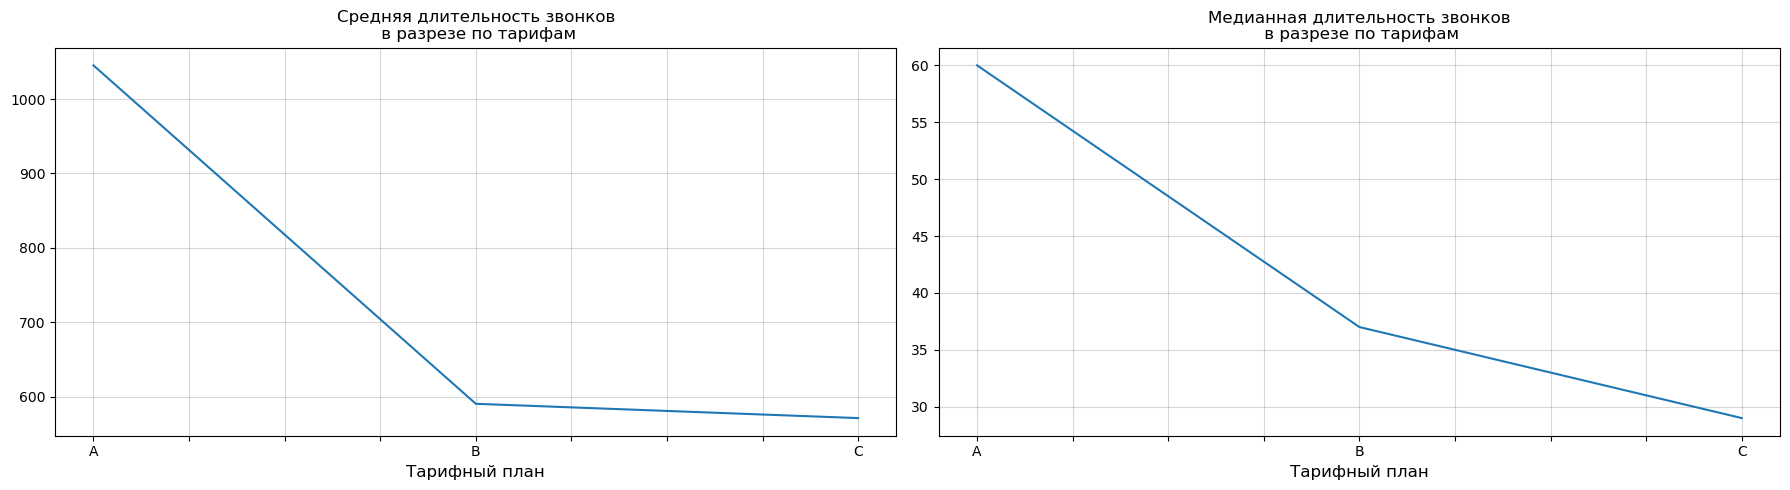

In [165]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

plt.subplot(1, 2, 1)
df.groupby('tariff_plan')['call_duration'].mean().plot()
plt.title('Средняя длительность звонков\n в разрезе по тарифам', fontsize=12)
plt.xlabel('Тарифный план', fontsize=12)
plt.grid(alpha=.5)

plt.subplot(1, 2, 2)
df.groupby('tariff_plan')['call_duration'].median().plot()
plt.title('Медианная длительность звонков\n в разрезе по тарифам', fontsize=12)
plt.xlabel('Тарифный план', fontsize=12)
plt.grid(alpha=.5)

plt.tight_layout()
plt.show()

***Судя по медианному и среднему значениям длительности звонков пользователи самого дорогого тарифа A чаще совершают длительные звонки, что, вероятно, делает данный тариф оправданным для их потребностей. Напротив, пользователи тарифов B и C совершают более короткие звонки, и если при этом платят за более высокие тарифные планы, это может указывать на потенциальную неоптимальность тарифа.***

***Для дальнейших выводов стоит рассмотреть совокупные финансовые расходы пользователей по тарифам, чтобы определить, кто из них переплачивает за услуги связи относительно фактического объема потребления.***

Добавим столбец с месяцем последнего использования клиентом услуг телеком-провайдера:

In [169]:
df['last_month'] = df.groupby('user_id')['month_call'].transform('max')
df.head()

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration,month_call,day_call,day_type,tariff_plan,date_start,last_month
0,166377,2019-09-02,in,False,880028,False,2,66,75,9,0,Будний день,B,2019-08-01,11
1,166377,2019-09-02,in,False,880026,False,1,31,34,9,0,Будний день,B,2019-08-01,11
2,166377,2019-09-02,out,False,880026,False,16,1853,1983,9,0,Будний день,B,2019-08-01,11
3,166377,2019-09-02,out,False,880026,True,6,0,168,9,0,Будний день,B,2019-08-01,11
4,166377,2019-09-02,out,False,880028,False,20,2529,2687,9,0,Будний день,B,2019-08-01,11


Проанализируем пропущенные вызовы - насколько часто происходят, есть ли зависимость от тарифа, на котором находится клиент:

In [171]:
df[df['is_missed_call'] == True].groupby('tariff_plan')['user_id'].count().sort_values(ascending=False)

tariff_plan
C    7851
B    7051
A    5000
Name: user_id, dtype: int64

In [172]:
print(f"Общая доля пропущенных вызовов: {round(df['is_missed_call'].mean()*100)}%")

Общая доля пропущенных вызовов: 43%


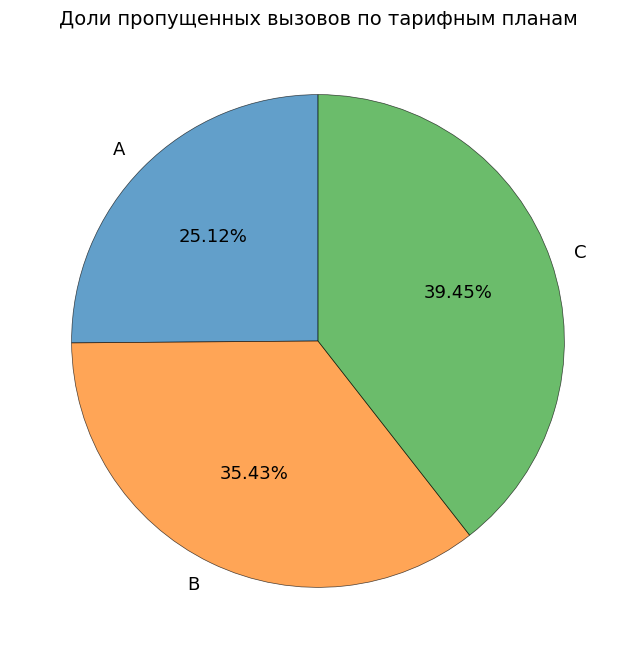

In [173]:
plt.figure(figsize=(16, 8))
missed_calls = df[df['is_missed_call'] == True].groupby('tariff_plan').size()

wedge_props = {'alpha': .7, 'edgecolor': 'black', 'linewidth': .5}
missed_calls.plot.pie(
    autopct='%1.2f%%',
    fontsize=13,
    wedgeprops=wedge_props,
    startangle=90,
    ylabel=''
)
plt.title("Доли пропущенных вызовов по тарифным планам", fontsize=14)
plt.show()

***На тарифе A (с более высокой абонентской платой) доля пропущенных вызовов ниже среднего. Это может свидетельствовать о более высокой вовлечённости пользователей, лучшем уровне доступности.***

***А на тарифах B и C доля пропущенных вызовов выше, особенно на одном из них (например, C), что может говорить о загруженности пользователей или ограничениях на тарифе (например, меньше минут, и люди не перезванивают).***

### 3.3. Анализ направлений звонков

Посмотрим сначала, информация о каких звонках в принципе представлена в датасете за указанный период больше - о входящих или исходящих:

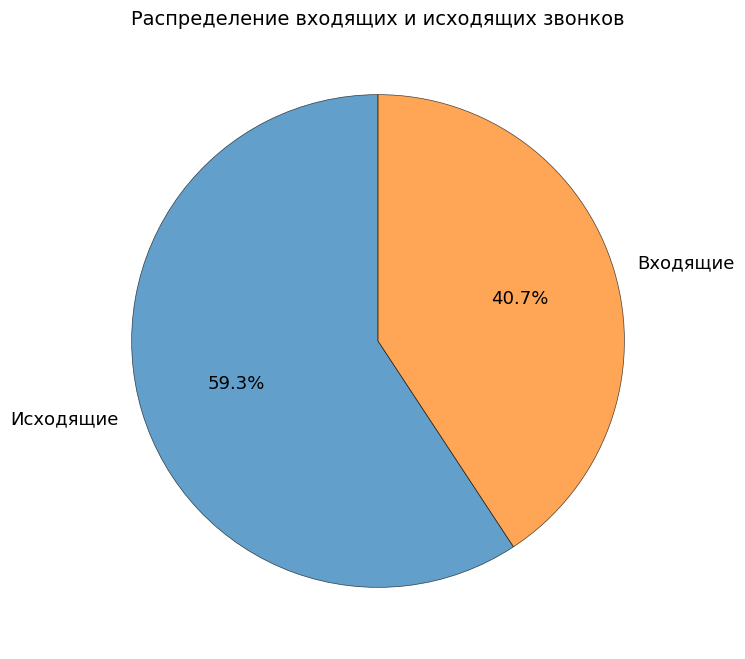

In [178]:
plt.figure(figsize=(16, 8))
wedge_props = {'alpha': .7, 'edgecolor': 'black', 'linewidth': .5}

df['direction'].value_counts(normalize=True).plot.pie(
    autopct='%1.1f%%',
    startangle=90,
    fontsize=13,
    labels=['Исходящие', 'Входящие'],
    ylabel='',
    wedgeprops=wedge_props
)
plt.title("Распределение входящих и исходящих звонков", fontsize=14)
plt.show()

In [179]:
df.groupby(['month_call', 'direction']).size().reset_index(name='calls_count')

,month_call,direction,calls_count
0,9,in,3310
1,9,out,4812
2,10,in,7003
3,10,out,9913
4,11,in,8638
5,11,out,12845


***На протяжении всех трех месяцев (сентябрь–ноябрь) исходящих звонков стабильно больше, чем входящих. Также наблюдается заметный рост звонков от месяца к месяцу, такой рост может быть связан с сезонностью (осень — традиционно деловая пора) или расширением клиентской базы телеком-провайдера.***

Теперь посмотрим на рапределение внутренних/внешних вызовов (каких больше за указанный период/ по месяцам):

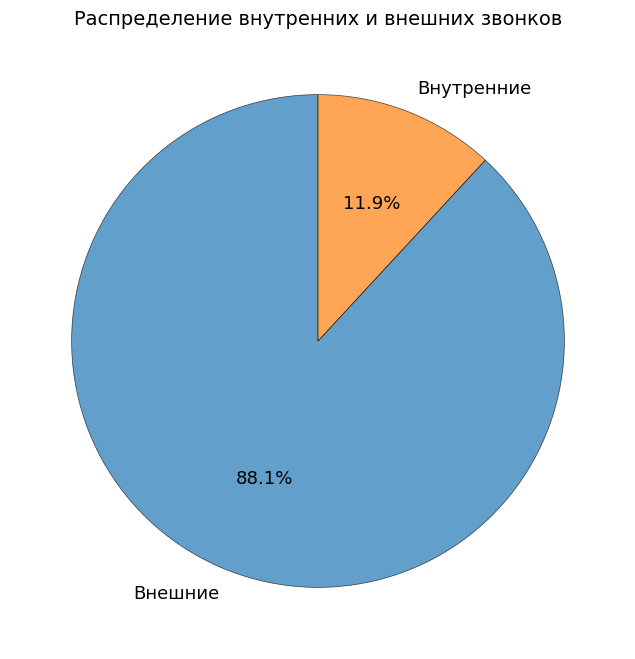

In [182]:
plt.figure(figsize=(16, 8))
wedge_props = {'alpha': .7, 'edgecolor': 'black', 'linewidth': .5}

df['internal'].value_counts(normalize=True).plot.pie(
    autopct='%1.1f%%',
    startangle=90,
    fontsize=13,
    labels=['Внешние', 'Внутренние'],
    ylabel='',
    wedgeprops=wedge_props
)

plt.title("Распределение внутренних и внешних звонков", fontsize=14)
plt.show()

In [183]:
monthly_internal = df.groupby(['month_call', 'internal']).size().reset_index(name='calls_count')
monthly_internal['internal'] = monthly_internal['internal'].map({True: 'Внутренние', False: 'Внешние'})
monthly_internal['total_calls_month'] = monthly_internal.groupby('month_call')['calls_count'].transform('sum')
monthly_internal['share_%'] = round(monthly_internal['calls_count'] / monthly_internal['total_calls_month'] * 100, 2)
monthly_internal

,month_call,internal,calls_count,total_calls_month,share_%
0,9,Внешние,7161,8122,88.17
1,9,Внутренние,961,8122,11.83
2,10,Внешние,15049,16916,88.96
3,10,Внутренние,1867,16916,11.04
4,11,Внешние,18785,21483,87.44
5,11,Внутренние,2698,21483,12.56


***Внешние звонки значительно преобладают над внутренними в каждом из месяцев, а также можно снова увидеть, что объём как внутренних, так и внешних звонков стабильно растёт от сентября к ноябрю.***

***Что интересно, доля внутренних звонков держится в пределах 12–13% от общего числа на протяжении всего периода. Это может указывать на устоявшийся формат внутренней коммуникации, либо ограниченное количество операторов, совершающих внутренние вызовы.***

### 3.4. Анализ поведения клиентов

Предварительно уберем из датасета строки со звонками, которые не распределились на операторов (значение `operator_id` = `0`). Не будем их учитывать в дальнейшем исследовании.

In [188]:
df = df[df['operator_id'] > 0]

In [189]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 39560 entries, 0 to 46519
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   user_id              39560 non-null  int32         
 1   date                 39560 non-null  datetime64[ns]
 2   direction            39560 non-null  object        
 3   internal             39560 non-null  bool          
 4   operator_id          39560 non-null  int32         
 5   is_missed_call       39560 non-null  bool          
 6   calls_count          39560 non-null  int16         
 7   call_duration        39560 non-null  int64         
 8   total_call_duration  39560 non-null  int64         
 9   month_call           39560 non-null  int32         
 10  day_call             39560 non-null  int32         
 11  day_type             39560 non-null  object        
 12  tariff_plan          39560 non-null  object        
 13  date_start           39560 non-null 

Добавим в наш датасет колонку с количеством операторов, которые обслуживают клиента:

In [191]:
operator_count = df.groupby(['user_id', 'month_call'])['operator_id'].transform('nunique')
df['operator_count'] = operator_count

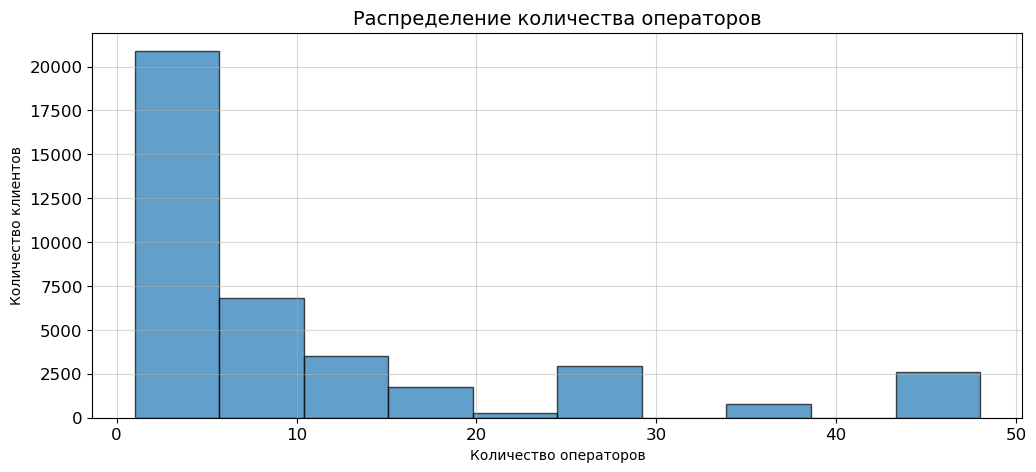

In [192]:
df['operator_count'].hist(edgecolor='black', alpha=.7, figsize=(12,5))

plt.title("Распределение количества операторов", fontsize=14)
plt.xlabel('Количество операторов')
plt.ylabel('Количество клиентов')
plt.tick_params(axis='both', labelsize=12)
plt.grid(True, alpha=.5)

plt.show()

In [193]:
df['operator_count'].max()

48

***Большинство клиентов пользуется услугами от 1 до 4 операторов, но встречаются и клиенты с бОльшим количеством операторов, максимальное значение - 48.***

Попробуем посмотреть, какой из тарифных планов предпочитают самые "разговорчивые" клиенты. Для понимания степени "разговорчивости" посмотрим, сколько времени в среднем пользователи проводят в звонках и распределим это по имеющимся тарифным планам:

In [197]:
user_call_duration = df.groupby(['user_id', 'tariff_plan'])['call_duration'].sum().reset_index()
avg_duration_by_tariff = user_call_duration.groupby('tariff_plan')['call_duration'].mean().sort_values(ascending=False).round()
avg_duration_by_tariff

tariff_plan
A    426217.0
B     94925.0
C     65359.0
Name: call_duration, dtype: float64

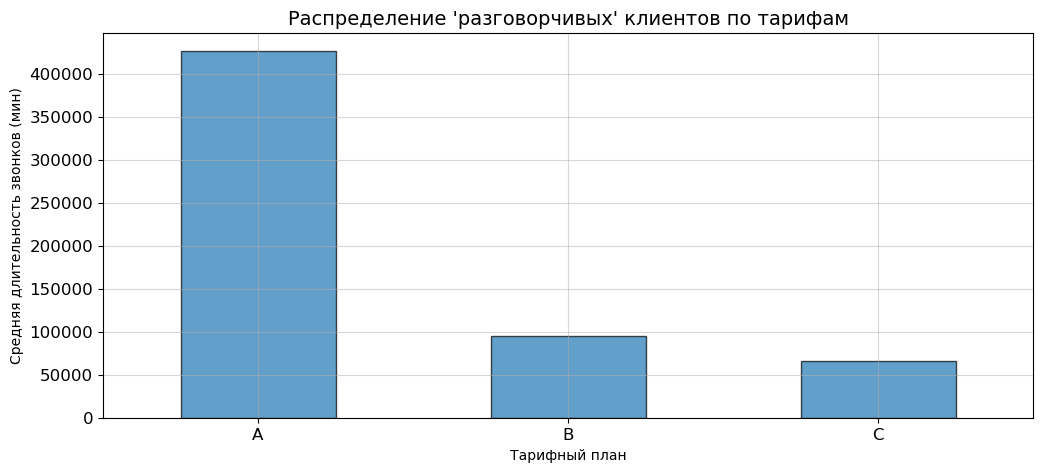

In [198]:
avg_duration_by_tariff.plot(kind='bar', edgecolor='black', alpha=.7, figsize=(12,5))
plt.title("Распределение 'разговорчивых' клиентов по тарифам", fontsize=14)

plt.ylabel("Средняя длительность звонков (мин)")
plt.xlabel("Тарифный план")
plt.tick_params(axis='both', labelsize=12)
plt.xticks(rotation=0)
plt.grid(alpha=.5)
plt.show()

***Тариф A (самый дорогой) — уверенно лидирует по средней суммарной длительности звонков на одного пользователя, в среднем клиенты на этом тарифе проговаривают ~426 217 минут — в 4–6 раз больше, чем клиенты на других тарифах. Это может говорить о том, что тариф А выбирают компании, у которых высокая нагрузка на линии связи. Это и есть наши самые "разговорчивые" пользователи.***

***Тарифы B и C заметно уступают, они рассчитаны на менее активных клиентов, также есть вероятность, что часть клиентов на этих тарифах не использует в полной мере доступные лимиты, что стоит учитывать при дальнейшем анализе неоптимальных тарифов.***

Далее выявим активных/ неактивных клиентов, **активными будем считать клиентов, по которым последние записи об использовании услуг телеком-провайдера были сформированы в ноябре,** остальные клиенты отвалились.

In [202]:
df['is_active_client'] = (df['last_month'] == df['last_month'].max())
df.head()

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration,month_call,day_call,day_type,tariff_plan,date_start,last_month,operator_count,is_active_client
0,166377,2019-09-02,in,False,880028,False,2,66,75,9,0,Будний день,B,2019-08-01,11,4,True
1,166377,2019-09-02,in,False,880026,False,1,31,34,9,0,Будний день,B,2019-08-01,11,4,True
2,166377,2019-09-02,out,False,880026,False,16,1853,1983,9,0,Будний день,B,2019-08-01,11,4,True
3,166377,2019-09-02,out,False,880026,True,6,0,168,9,0,Будний день,B,2019-08-01,11,4,True
4,166377,2019-09-02,out,False,880028,False,20,2529,2687,9,0,Будний день,B,2019-08-01,11,4,True


In [203]:
print("Количество уникальных активных пользователей:", df[df['is_active_client'] == True]['user_id'].nunique())
print(
    f"Доля активных пользователей: {df[df['is_active_client'] == True]['user_id'].nunique()/df['user_id'].nunique()*100:.2f}%"
)

Количество уникальных активных пользователей: 250
Доля активных пользователей: 87.72%


Добавим распределение активных пользователей по тарифам:

In [206]:
total_users = df.groupby('tariff_plan')['user_id'].nunique()
active_users = df[df['is_active_client'] == True].groupby('tariff_plan')['user_id'].nunique()

user_activity = pd.DataFrame({
    'total_users': total_users,
    'active_users': active_users
})

user_activity['active_%'] = (user_activity['active_users'] / user_activity['total_users'] * 100).round(2)
user_activity.reset_index()

,tariff_plan,total_users,active_users,active_%
0,A,30,28,93.33
1,B,100,89,89.00
2,C,155,133,85.81


***За исследуемый период, представленный в датасете, из 307 клиентов отказались от услуг провайдера 57 клиентов (это 18,6%). Также по приведенной выше таблице можно отметить, что самая высокая доля оттока клиентов на тарифе В, самая малая - на тарифе А (самом дорогом по абонентской плате).***

<div style="border:solid Chocolate 2px; padding: 40px">

***ВЫВОДЫ по Шагу 3:***

**Распределение клиентов по тарифам:**

Наиболее дорогой тариф A имеет наименьшее число клиентов (33 клиента), что соответствует рыночной закономерности: высокая абонентская плата ограничивает массовый спрос. Тарифы B (110 клиентов) и C (159 клиентов) демонстрируют практически равномерный уровень по количеству клиентов, что может указывать на сбалансированность их условий для среднестатистического пользователя.

**Поведение пользователей:**

Пользователи тарифа A отличаются высокой активностью: медианная и средняя длительность звонков значительно превышает показатели других тарифов (~426 217 минут на пользователя). Это позволяет предположить, что тариф A востребован среди крупных корпоративных клиентов или пользователей с высокой нагрузкой на линии связи.

Для тарифов B и C характерны более короткие по длительности звонки, что ставит под вопрос оптимальность выбора тарифа частью клиентов. Вероятно часть клиентов на этих тарифах не использует в полной мере доступные лимиты.

**Качество обслуживания и вовлеченность:**

Низкая доля пропущенных вызовов на тарифе A свидетельствует о высокой вовлеченности клиентов и, вероятно, лучшем уровне сервиса (например, приоритетное обслуживание). На тарифах B и C фиксируется более высокая доля пропущенных вызовов, что может объясняться ограниченными включенными минутами или менее гибкими условиями тарифа.

**Динамика звонков и сезонность:**

Наблюдается устойчивый рост исходящих звонков (сентябрь–ноябрь) с сохранением доли внутренних вызовов на уровне 12–13%. Это указывает на:

- сезонный фактор (активизация деловой активности осенью);
- стабильность внутренних коммуникаций (ограниченный круг абонентов, совершающих внутрисетевые звонки).

Внешние звонки преобладают (88% от общего объема), что подтверждает ориентацию клиентов на внешнюю коммуникацию.

**Неактивные клиенты:**

Доля отвалившихся клиентов составила 18,6% (57 из 307 клиентов). Для снижения этого показателя необходимо проанализировать причины ухода, особенно среди пользователей тарифов B и C, где потенциальная неоптимальность тарифа может влиять на лояльность.

# Шаг 4. Выявление клиентов с неоптимальными тарифами

### 4.1. Расчет затрат клиентов

Добавим в датасет столбцы с длительностью внешних исходящих вызовов и внутренних исходящих вызовов:

In [214]:
external_out_duration = df[
    (df['direction'] == 'out') &
    (df['internal'] == False)
].groupby(['user_id', 'month_call'])['total_call_duration'].sum().reset_index(name='external_out_call_duration')

df = df.merge(external_out_duration, on=['user_id', 'month_call'], how='left')
df['external_out_call_duration'] = df['external_out_call_duration'].fillna(0)
df.head()

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration,month_call,day_call,day_type,tariff_plan,date_start,last_month,operator_count,is_active_client,external_out_call_duration
0,166377,2019-09-02,in,False,880028,False,2,66,75,9,0,Будний день,B,2019-08-01,11,4,True,105835.0
1,166377,2019-09-02,in,False,880026,False,1,31,34,9,0,Будний день,B,2019-08-01,11,4,True,105835.0
2,166377,2019-09-02,out,False,880026,False,16,1853,1983,9,0,Будний день,B,2019-08-01,11,4,True,105835.0
3,166377,2019-09-02,out,False,880026,True,6,0,168,9,0,Будний день,B,2019-08-01,11,4,True,105835.0
4,166377,2019-09-02,out,False,880028,False,20,2529,2687,9,0,Будний день,B,2019-08-01,11,4,True,105835.0


In [215]:
internal_out_duration = df[
    (df['direction'] == 'out') &
    (df['internal'] == True)
].groupby(['user_id', 'month_call'])['total_call_duration'].sum().reset_index(name='internal_out_call_duration')

df = df.merge(internal_out_duration, on=['user_id', 'month_call'], how='left')
df['internal_out_call_duration'] = df['internal_out_call_duration'].fillna(0)
df.head()

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration,month_call,day_call,day_type,tariff_plan,date_start,last_month,operator_count,is_active_client,external_out_call_duration,internal_out_call_duration
0,166377,2019-09-02,in,False,880028,False,2,66,75,9,0,Будний день,B,2019-08-01,11,4,True,105835.0,9.0
1,166377,2019-09-02,in,False,880026,False,1,31,34,9,0,Будний день,B,2019-08-01,11,4,True,105835.0,9.0
2,166377,2019-09-02,out,False,880026,False,16,1853,1983,9,0,Будний день,B,2019-08-01,11,4,True,105835.0,9.0
3,166377,2019-09-02,out,False,880026,True,6,0,168,9,0,Будний день,B,2019-08-01,11,4,True,105835.0,9.0
4,166377,2019-09-02,out,False,880028,False,20,2529,2687,9,0,Будний день,B,2019-08-01,11,4,True,105835.0,9.0


Сгруппируем новый датафрейм с необходимыми для дальнейшего анализа данных колонками:

In [218]:
df_grouped = df[[
    'user_id',
    'month_call',
    'tariff_plan',
    'last_month',
    'operator_count',
    'is_active_client',
    'external_out_call_duration',
    'internal_out_call_duration'
]].drop_duplicates()
df_grouped.info()

<class 'pandas.core.frame.DataFrame'>
Index: 628 entries, 0 to 39551
Data columns (total 8 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   user_id                     628 non-null    int32  
 1   month_call                  628 non-null    int32  
 2   tariff_plan                 628 non-null    object 
 3   last_month                  628 non-null    int32  
 4   operator_count              628 non-null    int64  
 5   is_active_client            628 non-null    bool   
 6   external_out_call_duration  628 non-null    float64
 7   internal_out_call_duration  628 non-null    float64
dtypes: bool(1), float64(2), int32(3), int64(1), object(1)
memory usage: 32.5+ KB


Оформим данные в задаче стоимость тарифов и дополнительных услуг телеком-провайдера в датафрейм:

In [220]:
prices = pd.DataFrame(
    {
        'tariff_plan': ['A', 'B', 'C'],
        'price_month': [4000, 2000, 1000],
        'price_over_limit_out_internal': [0.1, 0.15, 0.3],
        'price_out_external': [0.3, 0.5, 0.7],
        'price_per_operator': [50, 150, 300],
        'included_internal_minutes': [2000, 500, 0]
    }
)
prices

,tariff_plan,price_month,price_over_limit_out_internal,price_out_external,price_per_operator,included_internal_minutes
0,A,4000,0.10,0.3,50,2000
1,B,2000,0.15,0.5,150,500
2,C,1000,0.30,0.7,300,0


Добавим тарифную информацию к данным клиентов:

In [222]:
df_grouped = df_grouped.merge(prices, on='tariff_plan', how='left')

Рассчитаем теперь текущую стоимость одного месяца пользования услугами телеком-провайдера для каждого клиента, а также гипотетически выгодную для клиента стоимость месяца пользования:

In [224]:
def calculate_monthly_cost(df_grouped, prices):
    # текущая стоимость
    df_grouped['current_price'] = (
        df_grouped['price_month'] +
        (df_grouped['internal_out_call_duration'] - df_grouped['included_internal_minutes']).clip(0) *
        df_grouped['price_over_limit_out_internal'] +
        df_grouped['external_out_call_duration'] * df_grouped['price_out_external'] +
        (df_grouped['operator_count'] - 1).clip(0) * df_grouped['price_per_operator']
    )

    # гипотетическая стоимость
    for tariff in ['A', 'B', 'C']:
        tariff_params = prices[prices['tariff_plan'] == tariff].iloc[0]

        df_grouped[f'price_if_{tariff}'] = (
            tariff_params['price_month'] +
            (df_grouped['internal_out_call_duration'] - df_grouped['included_internal_minutes']).clip(0) *
            tariff_params['price_over_limit_out_internal'] +
            df_grouped['external_out_call_duration'] * tariff_params['price_out_external'] +
            (df_grouped['operator_count'] - 1).clip(0) * tariff_params['price_per_operator']
        )

    return df_grouped

In [225]:
df_grouped = calculate_monthly_cost(df_grouped, prices)
df_grouped.head()

,user_id,month_call,tariff_plan,last_month,operator_count,is_active_client,external_out_call_duration,internal_out_call_duration,price_month,price_over_limit_out_internal,price_out_external,price_per_operator,included_internal_minutes,current_price,price_if_A,price_if_B,price_if_C
0,166377,9,B,11,4,True,105835.0,9.0,2000,0.15,0.5,150,500,55367.5,35900.5,55367.5,75984.5
1,166377,10,B,11,5,True,99207.0,5.0,2000,0.15,0.5,150,500,52203.5,33962.1,52203.5,71644.9
2,166377,11,B,11,4,True,95383.0,127.0,2000,0.15,0.5,150,500,50141.5,32764.9,50141.5,68668.1
3,166391,9,C,11,1,True,0.0,0.0,1000,0.30,0.7,300,0,1000.0,4000.0,2000.0,1000.0
4,166391,11,C,11,1,True,0.0,0.0,1000,0.30,0.7,300,0,1000.0,4000.0,2000.0,1000.0


In [227]:
df_grouped.query('user_id == 166377').query('month_call == 9')

,user_id,month_call,tariff_plan,last_month,operator_count,is_active_client,external_out_call_duration,internal_out_call_duration,price_month,price_over_limit_out_internal,price_out_external,price_per_operator,included_internal_minutes,current_price,price_if_A,price_if_B,price_if_C
0,166377,9,B,11,4,True,105835.0,9.0,2000,0.15,0.5,150,500,55367.5,35900.5,55367.5,75984.5


Колонки, которые мы использовали для подсчета, нам больше не нужны, поэтому выведем только те колонки, которые нам потребуются для дальнейшего анализа:

In [230]:
df_grouped = df_grouped[[
    'user_id',
    'month_call',
    'tariff_plan',
    'last_month',
    'is_active_client',
    'current_price',
    'price_if_A',
    'price_if_B',
    'price_if_C'
]]
df_grouped.head()

,user_id,month_call,tariff_plan,last_month,is_active_client,current_price,price_if_A,price_if_B,price_if_C
0,166377,9,B,11,True,55367.5,35900.5,55367.5,75984.5
1,166377,10,B,11,True,52203.5,33962.1,52203.5,71644.9
2,166377,11,B,11,True,50141.5,32764.9,50141.5,68668.1
3,166391,9,C,11,True,1000.0,4000.0,2000.0,1000.0
4,166391,11,C,11,True,1000.0,4000.0,2000.0,1000.0


Добавим столбцы с оптимальной тарифной стоимостью, оптимальным тарифным планом для клиента, а также суммой переплаты:

In [232]:
df_grouped['optimal_price'] = df_grouped[['current_price', 'price_if_A', 'price_if_B', 'price_if_C']].min(axis=1)
df_grouped.head()

,user_id,month_call,tariff_plan,last_month,is_active_client,current_price,price_if_A,price_if_B,price_if_C,optimal_price
0,166377,9,B,11,True,55367.5,35900.5,55367.5,75984.5,35900.5
1,166377,10,B,11,True,52203.5,33962.1,52203.5,71644.9,33962.1
2,166377,11,B,11,True,50141.5,32764.9,50141.5,68668.1,32764.9
3,166391,9,C,11,True,1000.0,4000.0,2000.0,1000.0,1000.0
4,166391,11,C,11,True,1000.0,4000.0,2000.0,1000.0,1000.0


In [233]:
df_grouped['optimal_tariff'] = df_grouped[['price_if_A', 'price_if_B', 'price_if_C']].idxmin(axis=1)
df_grouped['optimal_tariff'] = df_grouped['optimal_tariff'].str.replace('price_if_', '')

In [234]:
df_grouped['overpayment'] = df_grouped['current_price'] - df_grouped['optimal_price']
df_grouped.head()

,user_id,month_call,tariff_plan,last_month,is_active_client,current_price,price_if_A,price_if_B,price_if_C,optimal_price,optimal_tariff,overpayment
0,166377,9,B,11,True,55367.5,35900.5,55367.5,75984.5,35900.5,A,19467.0
1,166377,10,B,11,True,52203.5,33962.1,52203.5,71644.9,33962.1,A,18241.4
2,166377,11,B,11,True,50141.5,32764.9,50141.5,68668.1,32764.9,A,17376.6
3,166391,9,C,11,True,1000.0,4000.0,2000.0,1000.0,1000.0,C,0.0
4,166391,11,C,11,True,1000.0,4000.0,2000.0,1000.0,1000.0,C,0.0


In [235]:
#df_grouped = df_grouped.drop_duplicates()
#df_grouped.duplicated().sum()

Теперь посмотрим отдельно на активных и неактивных клиентов, маркер активности был добавлен ранее столбцом `is_active_client`, сформируем два датафрейма для каждого вида клиентов:

In [240]:
df_nonactive = df_grouped[df_grouped['is_active_client'] == False]
df_nonactive.head()

,user_id,month_call,tariff_plan,last_month,is_active_client,current_price,price_if_A,price_if_B,price_if_C,optimal_price,optimal_tariff,overpayment
8,166399,9,C,10,False,1000.0,4000.0,2000.0,1000.0,1000.0,C,0.0
9,166399,10,C,10,False,1000.0,4000.0,2000.0,1000.0,1000.0,C,0.0
73,166671,9,C,10,False,1000.0,4000.0,2000.0,1000.0,1000.0,C,0.0
74,166671,10,C,10,False,1000.0,4000.0,2000.0,1000.0,1000.0,C,0.0
111,166727,9,C,10,False,1000.0,4000.0,2000.0,1000.0,1000.0,C,0.0


В тех случаях, если переплата (столбец `overpayment`) равна `0`, для этих клиентов мы ничего предложить не сможем, кроме как снизить стоимость тарифов (однако этот факт вне зоны нашей ответственности), поэтому рассмотрим только тех, у кого переплата по сравнению с оптимальным тарифом больше `0`:

In [242]:
df_nonactive = df_nonactive[df_nonactive['overpayment'] > 0]
print("Количество клиентов-отвалов с неоптимальными тарифами:", df_nonactive['user_id'].nunique())

Количество клиентов-отвалов с неоптимальными тарифами: 18


В теории можно посмотреть, что мы могли бы сделать для этих 18 клиентов, которые переплачивали, находясь на своем тарифе, для этого рассчитаем медианное значение переплаты для таких клиентов и предположим, что тех, кто переплачивал больше медианного значения, можно было бы вернуть с помощью перевода их на более оптимальный тариф.

In [244]:
df_nonactive.drop_duplicates(subset=['user_id'])['overpayment'].median()

2476.0

In [245]:
df_nonactive[df_nonactive['overpayment'] > 2476.0]['user_id'].unique()

array([166941, 167011, 167053, 167124, 167125, 167141, 167645, 167819,
       168025])

In [246]:
df_nonactive['user_id'].unique()

array([166936, 166941, 166946, 166958, 167011, 167053, 167122, 167124,
       167125, 167130, 167141, 167285, 167288, 167551, 167645, 167819,
       168025, 168093])

Составим для этих пользователей табличку с их прошлым тарифным планом и гипотетически выгодным тарифным планом:

In [248]:
return_clients = []
for user in df_nonactive['user_id']:
    user_data = df_nonactive[df_nonactive['user_id'] == user]

    return_clients.append({
        'ИД пользователя': user,
        'Текущий тариф пользователя': user_data['tariff_plan'].values[0],
        'Гипотетически выгодный тариф для пользователя': user_data['optimal_tariff'].values[0],
        'Сумма переплаты': user_data['overpayment'].values[0]
    })

return_clients_df = pd.DataFrame(return_clients)

return_clients_df = return_clients_df.drop_duplicates()

return_clients_df.sort_values(by='Сумма переплаты', ascending=False)

,ИД пользователя,Текущий тариф пользователя,Гипотетически выгодный тариф для пользователя,Сумма переплаты
10,167125,C,A,241500.20
5,167011,C,A,149157.00
20,168025,B,A,57362.00
19,167819,C,A,11430.80
1,166941,B,A,6725.60
8,167124,B,A,6702.80
13,167141,B,A,5909.20
6,167053,C,A,5757.60
18,167645,C,A,3308.00
21,168093,C,A,1644.00


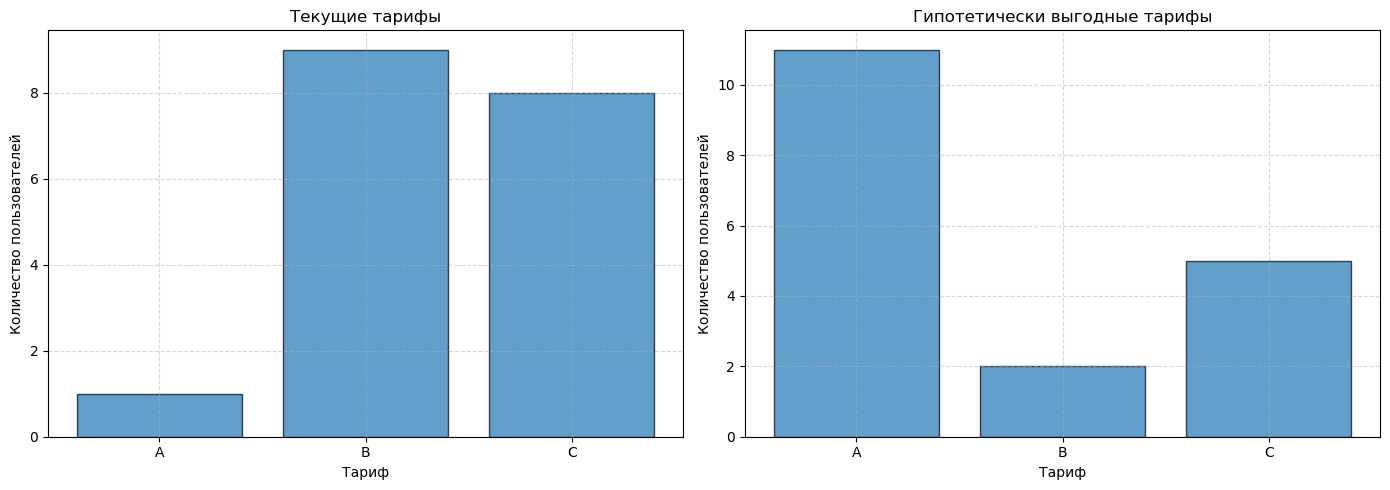

In [249]:
current_counts = return_clients_df['Текущий тариф пользователя'].value_counts().sort_index()
recommended_counts = return_clients_df['Гипотетически выгодный тариф для пользователя'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(current_counts.index, current_counts.values, edgecolor='black', alpha=.7)
axes[0].set_title("Текущие тарифы")
axes[0].set_xlabel("Тариф")
axes[0].set_ylabel("Количество пользователей")
axes[0].grid(linestyle='--', alpha=.5)

axes[1].bar(recommended_counts.index, recommended_counts.values, edgecolor='black', alpha=.7)
axes[1].set_title("Гипотетически выгодные тарифы")
axes[1].set_xlabel("Тариф")
axes[1].set_ylabel("Количество пользователей")
axes[1].grid(linestyle='--', alpha=.5)

plt.tight_layout()
plt.show()

***Что любопытно, для неактивных сейчас клиентов тариф А оказался самым выгодным на основании 4 месяцев лога звонков, представленных в нашем датасете, несмотря на то что его изначально выбирали единицы. Это говорит о недоинформированности пользователей о выгодности этого тарифа. Да, абонентская плата самая высокая, однако в перспективе на основании большого объема дополнительных услуг его было бы использовать выгоднее.***

***Некоторым пользователям наоборот выгоднее перейти на тариф C, это может быть связано с малым объемом потребления услуг. Тариф B для данного пула клиентов — почти не выгоден. Есть потенциал для автоматической рекомендации тарифов: например, если внедрить систему автоматических подсказок, можно существенно сократить издержки пользователей и повысить их лояльность.***

Теперь сформируем датафрейм для активных клиентов (напомним, это те, кто пользовались сервисом в течение последнего, указанного в данных, месяца) и посмотрим, есть ли у них потенциально невыгодные для них тарифы:

In [253]:
df_active = df_grouped[df_grouped['is_active_client'] == True]
print(f'Количество активных клиентов компании: {df_active["user_id"].nunique()}')

Количество активных клиентов компании: 250


In [256]:
df_active.head()

,user_id,month_call,tariff_plan,last_month,is_active_client,current_price,price_if_A,price_if_B,price_if_C,optimal_price,optimal_tariff,overpayment
0,166377,9,B,11,True,55367.5,35900.5,55367.5,75984.5,35900.5,A,19467.0
1,166377,10,B,11,True,52203.5,33962.1,52203.5,71644.9,33962.1,A,18241.4
2,166377,11,B,11,True,50141.5,32764.9,50141.5,68668.1,32764.9,A,17376.6
3,166391,9,C,11,True,1000.0,4000.0,2000.0,1000.0,1000.0,C,0.0
4,166391,11,C,11,True,1000.0,4000.0,2000.0,1000.0,1000.0,C,0.0


In [257]:
df_grouped[df_grouped['is_active_client'] == True]['user_id'].nunique()

250

In [258]:
df_active.info()

<class 'pandas.core.frame.DataFrame'>
Index: 575 entries, 0 to 627
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   user_id           575 non-null    int32  
 1   month_call        575 non-null    int32  
 2   tariff_plan       575 non-null    object 
 3   last_month        575 non-null    int32  
 4   is_active_client  575 non-null    bool   
 5   current_price     575 non-null    float64
 6   price_if_A        575 non-null    float64
 7   price_if_B        575 non-null    float64
 8   price_if_C        575 non-null    float64
 9   optimal_price     575 non-null    float64
 10  optimal_tariff    575 non-null    object 
 11  overpayment       575 non-null    float64
dtypes: bool(1), float64(6), int32(3), object(2)
memory usage: 47.7+ KB


In [259]:
df_active[df_active['user_id'] == 166377]

,user_id,month_call,tariff_plan,last_month,is_active_client,current_price,price_if_A,price_if_B,price_if_C,optimal_price,optimal_tariff,overpayment
0,166377,9,B,11,True,55367.5,35900.5,55367.5,75984.5,35900.5,A,19467.0
1,166377,10,B,11,True,52203.5,33962.1,52203.5,71644.9,33962.1,A,18241.4
2,166377,11,B,11,True,50141.5,32764.9,50141.5,68668.1,32764.9,A,17376.6


Сразу хочется обратить внимание, есть ли среди наших активных клиентов те, кто не переплачивает в данный момент за услуги связи, и действительно находится на самом выгодном тарифном плане:

In [264]:
df_optimal_users = df_active.groupby("user_id")["overpayment"].sum().reset_index()

print(f'Клиенты с переплатой за весь период: {df_optimal_users[df_optimal_users["overpayment"] > 0]["user_id"].nunique()}')
print(f'Клиенты без переплаты за весь период: {df_optimal_users[df_optimal_users["overpayment"] <= 0]["user_id"].nunique()}')

Клиенты с переплатой за весь период: 159
Клиенты без переплаты за весь период: 91


***Получается все-таки меньшее количество (91 клиент) пользуется услугами телеком-провайдера на самых выгодных условиях.***

***Остальные (159 клиентов) находятся на неоптимальных тарифах и регулярно переплачивают за услуги связи. Это тревожный сигнал: такие пользователи могут быть менее удовлетворены качеством обслуживания и находятся в зоне риска отвала. Особенно если они узнают о переплате, либо если конкуренты предложат им более выгодные условия.***

Для дальнейших расчетов оставим в датасете с активными клиентами только уникальных пользователей:

In [271]:
df_user_stats = df_active.groupby('user_id').agg({
    'tariff_plan': 'max',
    'month_call':'max',
    'current_price': 'sum',              
    'price_if_A': 'mean',
    'price_if_B': 'mean',
    'price_if_C': 'mean',
    'optimal_price': 'mean',
    'optimal_tariff': 'max',
    'overpayment':'mean'                 
}).reset_index().round()
df_user_stats.head()

,user_id,tariff_plan,month_call,current_price,price_if_A,price_if_B,price_if_C,optimal_price,optimal_tariff,overpayment
0,166377,B,11,157712.0,34209.0,52571.0,72099.0,34209.0,A,18362.0
1,166391,C,11,2000.0,4000.0,2000.0,1000.0,1000.0,C,0.0
2,166392,C,11,3900.0,4050.0,2150.0,1300.0,1300.0,C,0.0
3,166405,B,11,459935.0,94535.0,153312.0,213415.0,94535.0,A,58777.0
4,166406,B,11,141562.0,31073.0,47187.0,64362.0,31073.0,A,16114.0


In [278]:
df_active.query('user_id == 166377')

,user_id,month_call,tariff_plan,last_month,is_active_client,current_price,price_if_A,price_if_B,price_if_C,optimal_price,optimal_tariff,overpayment
0,166377,9,B,11,True,55367.5,35900.5,55367.5,75984.5,35900.5,A,19467.0
1,166377,10,B,11,True,52203.5,33962.1,52203.5,71644.9,33962.1,A,18241.4
2,166377,11,B,11,True,50141.5,32764.9,50141.5,68668.1,32764.9,A,17376.6


Посмотрим на распределение переплат у данных клиентов с помощью диаграммы размаха:

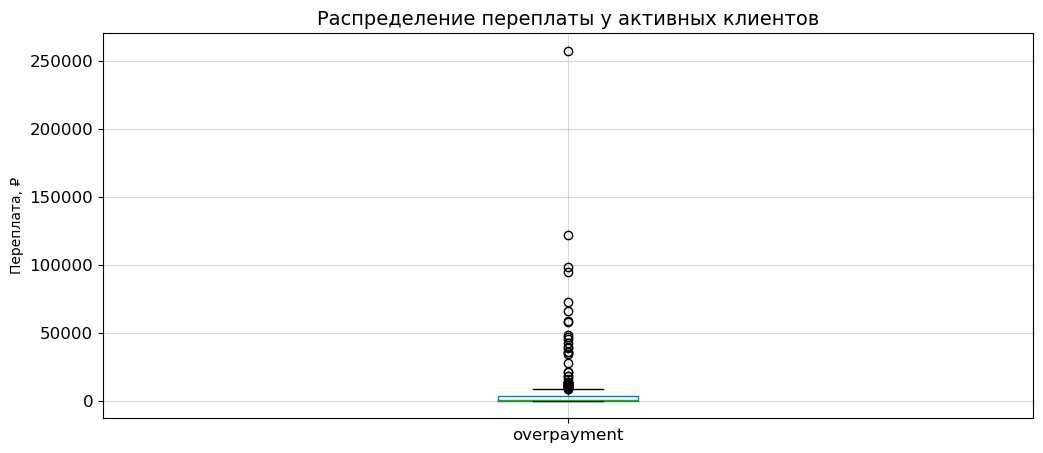

In [281]:
plt.figure(figsize=(12, 5))

df_user_stats[['overpayment']].boxplot()
plt.title("Распределение переплаты у активных клиентов", fontsize=14)
plt.ylabel("Переплата, ₽")
plt.tick_params(axis='both', labelsize=12)
plt.grid(True, alpha=.5)

plt.show()

In [282]:
df_user_stats['overpayment_percentage'] = round(df_user_stats['overpayment'] / df_user_stats['optimal_price'] * 100)
df_user_stats.head()

,user_id,tariff_plan,month_call,current_price,price_if_A,price_if_B,price_if_C,optimal_price,optimal_tariff,overpayment,overpayment_percentage
0,166377,B,11,157712.0,34209.0,52571.0,72099.0,34209.0,A,18362.0,54.0
1,166391,C,11,2000.0,4000.0,2000.0,1000.0,1000.0,C,0.0,0.0
2,166392,C,11,3900.0,4050.0,2150.0,1300.0,1300.0,C,0.0,0.0
3,166405,B,11,459935.0,94535.0,153312.0,213415.0,94535.0,A,58777.0,62.0
4,166406,B,11,141562.0,31073.0,47187.0,64362.0,31073.0,A,16114.0,52.0


In [283]:
df_user_stats['overpayment_percentage'].describe()

count    250.00000
mean      37.21600
std       50.31269
min        0.00000
25%        0.00000
50%       16.50000
75%       61.00000
max      300.00000
Name: overpayment_percentage, dtype: float64

In [284]:
median = df_user_stats['overpayment_percentage'].median()
q3 = df_user_stats['overpayment_percentage'].quantile(0.75)
print(f"Медиана: {median:.2f} %, Q3 (75%): {q3:.2f} %")

high_risk = df_user_stats[df_user_stats['overpayment_percentage'] > q3]
print(f"Клиентов в зоне высокого риска: {len(high_risk)}")

Медиана: 16.50 %, Q3 (75%): 61.00 %
Клиентов в зоне высокого риска: 61


Выведем список клиентов, которые находятся в зоне риска, значение переплаты выше медианного значения:

In [289]:
df_user_stats[df_user_stats['overpayment_percentage'] > median][
    ['user_id', 'tariff_plan', 'optimal_tariff', 'optimal_price', 'overpayment']
].sort_values(by='overpayment', ascending=False)

,user_id,tariff_plan,optimal_tariff,optimal_price,overpayment
157,167827,C,A,199130.0,257540.0
24,166658,B,A,188398.0,121888.0
233,168412,C,A,79022.0,98497.0
164,167888,C,A,77189.0,94952.0
64,166983,C,A,60244.0,72898.0
...,...,...,...,...,...
227,168307,B,C,2290.0,535.0
102,167250,B,C,2930.0,500.0
49,166837,B,C,2000.0,500.0
194,168047,B,C,2815.0,482.0


И отдельно выведем список клиентов, которые находятся в зоне повышенного риска (значения переплаты выше 75 процентиля):

In [291]:
high_risk_clients = df_user_stats[df_user_stats['overpayment_percentage'] > q3][
    ['user_id', 'tariff_plan', 'optimal_tariff', 'optimal_price', 'overpayment']
].sort_values(by='overpayment', ascending=False)
high_risk_clients

,user_id,tariff_plan,optimal_tariff,optimal_price,overpayment
157,167827,C,A,199130.0,257540.0
24,166658,B,A,188398.0,121888.0
233,168412,C,A,79022.0,98497.0
164,167888,C,A,77189.0,94952.0
64,166983,C,A,60244.0,72898.0
...,...,...,...,...,...
6,166428,B,C,1200.0,900.0
83,167110,B,C,1352.0,867.0
103,167263,B,C,1365.0,853.0
192,168041,B,C,1300.0,850.0


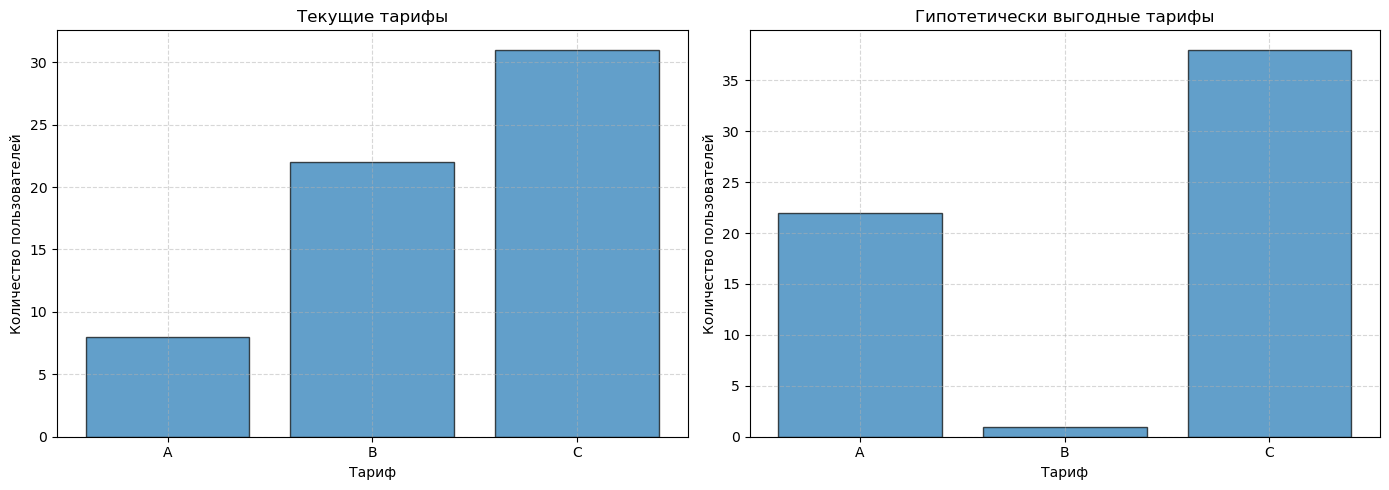

In [292]:
current_counts_active = high_risk_clients['tariff_plan'].value_counts().sort_index()
recommended_counts_active = high_risk_clients['optimal_tariff'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(current_counts_active.index, current_counts_active.values, edgecolor='black', alpha=.7)
axes[0].set_title("Текущие тарифы")
axes[0].set_xlabel("Тариф")
axes[0].set_ylabel("Количество пользователей")
axes[0].grid(linestyle='--', alpha=.5)

axes[1].bar(recommended_counts_active.index, recommended_counts_active.values, edgecolor='black', alpha=.7)
axes[1].set_title("Гипотетически выгодные тарифы")
axes[1].set_xlabel("Тариф")
axes[1].set_ylabel("Количество пользователей")
axes[1].grid(linestyle='--', alpha=.5)

plt.tight_layout()
plt.show()

***Максимальная переплата одного клиента — 257 540 ₽. Такие клиенты — это "красные флаги", которые могут уйти к конкурентам при первом же выгодном предложении.***

***Большинство клиентов из списка — на тарифе В. Возможно тариф В выбирали как среднее между самым высоким по абонентке тарифом и самым недорогим, но на практике не соответствует их фактическому потреблению.***

***Во многих случаях гипотетически выгодный тариф — С, важно учитывать также, что клиенты с переплатой выше 50 000 ₽ особенно чувствительны к предложениям конкурентов и могут быть утеряны в краткосрочной перспективе.***

### 4.2. Подсчет выручки компании

Рассчитывать выручку будем на активных клиентах и посмотрим на основании последнего месяца логов звонков, в датафрейме `df_user_stats` уже представлены уникальные активные пользователи и последний месяц:

In [297]:
current_revenue = round(df_user_stats['optimal_price'] + df_user_stats['overpayment']).sum()
print(f'Выручка за месяц при текущих тарифных планах: {current_revenue} ₽.')

Выручка за месяц при текущих тарифных планах: 5564605.0 ₽.


In [298]:
best_price_revenue = round(df_user_stats['optimal_price'].sum()
)

print(f'Выручка при гипотетически выгодных тарифных планах за месяц: {best_price_revenue} ₽.')

Выручка при гипотетически выгодных тарифных планах за месяц: 3814896 ₽.


In [299]:
loss_percentage = ((current_revenue - best_price_revenue) / current_revenue) * 100
print(
    f'Потеря в выручке для компании: {current_revenue - best_price_revenue} ₽ или {loss_percentage:.2f}%.'.replace(',', ' ')
)

Потеря в выручке для компании: 1749709.0 ₽ или 31.44%.


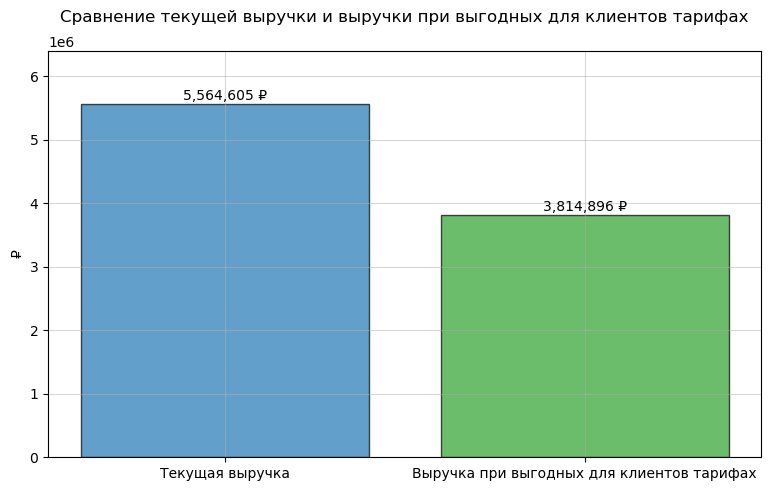

In [300]:
labels = ['Текущая выручка', 'Выручка при выгодных для клиентов тарифах']
values = [current_revenue, best_price_revenue]

plt.figure(figsize=(8, 5))
bars = plt.bar(labels, values, color=['#1f77b4', '#2ca02c'], edgecolor='black', alpha=.7)

max_value = max(values)
plt.ylim(0, max_value * 1.15)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 10000,
             f'{height:,.0f} ₽', ha='center', va='bottom')

plt.title('Сравнение текущей выручки и выручки при выгодных для клиентов тарифах', y=1.05)
plt.ylabel('₽')
plt.grid(alpha=.5)
plt.tight_layout()
plt.show()

***Перевод клиентов на более выгодные для них тарифные планы приведёт к снижению выручки компании на 1 749 709 ₽ (31,44%).***

Несмотря на то, что полный перевод всех клиентов на оптимальные тарифные планы теоретически возможен, на практике он приведёт к существенному снижению выручки компании — более 30 %. Такой сценарий экономически нецелесообразен.

Однако, с точки зрения снижения рисков отвала, целесообразно рассмотреть какую-то границу в значении переплаты, чтобы сохранить по возможности лояльность клиентов, а также не сильно потерять в выручке. Попробуем посчитать выручку в том случае, если мы переведем на оптимальные тарифы клиентов со средним значением переплаты более 50 000 р/ мес, эти клиенты, скорее всего, наиболее чувствительны к цене и в случае отсутствия корректирующих действий со стороны компании, могут перейти к конкурентам.

In [303]:
max_risk_clients = df_user_stats[df_user_stats['overpayment'] > 50000][
    ['user_id', 'month_call', 'tariff_plan', 'optimal_tariff', 'optimal_price', 'overpayment']
].sort_values(by='overpayment', ascending=False)
max_risk_clients

,user_id,month_call,tariff_plan,optimal_tariff,optimal_price,overpayment
157,167827,11,C,A,199130.0,257540.0
24,166658,11,B,A,188398.0,121888.0
233,168412,11,C,A,79022.0,98497.0
164,167888,11,C,A,77189.0,94952.0
64,166983,11,C,A,60244.0,72898.0
12,166511,11,C,A,55255.0,65722.0
3,166405,11,B,A,94535.0,58777.0
86,167150,11,C,A,48151.0,58009.0


In [304]:
max_risk_revenue =  max_risk_clients['optimal_price'].sum()

low_risk_clients = df_user_stats[df_user_stats['overpayment'] <= 50000]
low_risk_revenue = (low_risk_clients['optimal_price'] + low_risk_clients['overpayment']).sum()

In [305]:
total_max_revenue = round(max_risk_revenue + low_risk_revenue, 2)
print(
    f"Общая выручка при переводе высокорисковых клиентов на оптимальные тарифы, \nа остальных — при сохранении на текущих: {total_max_revenue} ₽"
)

Общая выручка при переводе высокорисковых клиентов на оптимальные тарифы, 
а остальных — при сохранении на текущих: 4736322.0 ₽


In [306]:
max_loss_percentage_ = ((current_revenue - total_max_revenue) / current_revenue) * 100
print(
    f'Потеря в выручке для компании: {round(current_revenue - total_max_revenue, 2)} ₽ или {max_loss_percentage_:.2f}%.'.replace(',', ' ')
)

Потеря в выручке для компании: 828283.0 ₽ или 14.88%.


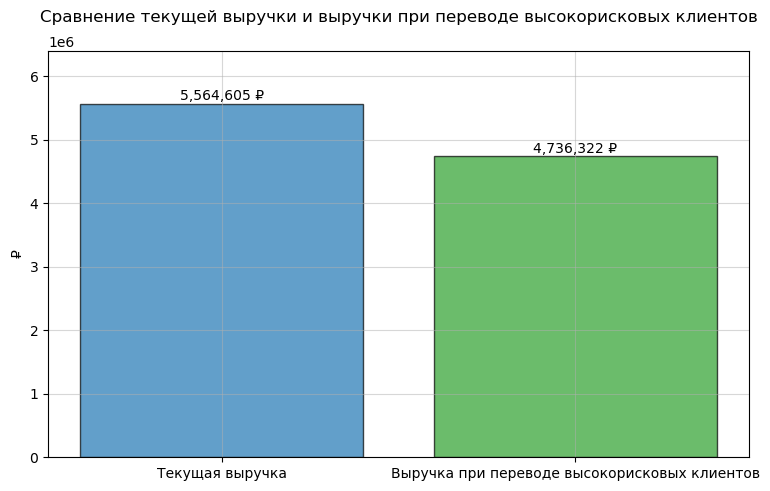

In [307]:
labels = ['Текущая выручка', 'Выручка при переводе высокорисковых клиентов']
values = [current_revenue, total_max_revenue]

plt.figure(figsize=(8, 5))
bars = plt.bar(labels, values, color=['#1f77b4', '#2ca02c'], edgecolor='black', alpha=.7)

max_value = max(values)
plt.ylim(0, max_value * 1.15)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 10000,
             f'{height:,.0f} ₽', ha='center', va='bottom')

plt.title('Сравнение текущей выручки и выручки при переводе высокорисковых клиентов', y=1.05)
plt.ylabel('₽')
plt.grid(alpha=.5)
plt.tight_layout()
plt.show()

***Если оптимизировать тарифы только для клиентов с крайне высоким значением переплаты, потери сократятся до 828 283 ₽ (14,88%), что делает этот вариант более сбалансированным. Таким образом, фокусировка на клиентах с высоким риском отвала позволяет минимизировать снижение выручки, сохраняя при этом лояльность ключевой аудитории. Это стратегически более выгодный подход для компании.***

<div class="alert alert-success">
    
**Комментарий ревьюера**

**#ок**

Хорошо, это возможное направление дополнительного анализа.
</div>

<div style="border:solid Chocolate 2px; padding: 40px">

***ВЫВОДЫ по Шагу 4:***

**Оптимальность тарифного плана A:**

Несмотря на наименьшую популярность среди клиентов, тариф A оказался наиболее выгодным по итогам анализа звонковых логов за последние 4 месяца. Это говорит о вероятной недоинформированности клиентов: тариф имеет высокую абонентскую плату, однако при интенсивном потреблении дополнительных услуг он обеспечивает наименьшие совокупные расходы. 

**Релевантность тарифов C и B:**

Некоторым клиентам оказался выгоднее тариф C, что свидетельствует о низком уровне их потребления. Это подчёркивает необходимость персонализированного подхода при выборе тарифного плана. Тариф B в текущей выборке оказался практически нерелевантным — он редко оказывался оптимальным, что может указывать на его неэффективность с точки зрения клиентской ценности.

**Потенциал автоматических рекомендаций:**

Выявленные диспропорции в выборе тарифов открывают возможности для внедрения системы автоматических рекомендаций тарифов. Такие рекомендации позволят клиентам оптимизировать расходы, а компании — повысить лояльность, снизить отток и укрепить конкурентные преимущества.

**Анализ клиентской базы:**

91 клиентов уже находятся на оптимальных тарифах — это положительный сигнал о частичном совпадении предпочтений клиентов и их потребительского профиля.

159 клиент переплачивает за услуги связи — это тревожная зона: высокая вероятность отвала при появлении альтернативных предложений со стороны конкурентов.

Максимальная зарегистрированная переплата составила 257 540 ₽ — такие клиенты находятся в критической зоне риска и требуют индивидуального внимания.

**Выбор тарифа C большинством клиентов:**

Значительная доля клиентов, особенно тех, кто переплачивает, пользуется тарифом C. Это может указывать на то, что он выбран по умолчанию или в рамках базовой коммуникации, однако не соответствует фактическим паттернам потребления.

**Финансовое моделирование изменений тарифной политики:**

- Массовый перевод всех клиентов на оптимальные тарифы приведёт к снижению выручки на 31,44% — решение с высоким уровнем риска, неприемлемое в текущем виде.

- Альтернативный сценарий, при котором оптимизируются тарифы только для клиентов с высоким значением переплаты (> 50 000 р/мес), потери сократятся до 14,88%, что выглядит более сбалансированным по отношению к риску отвала и финансовому эффекту.

<div class="alert alert-success">
    
**Комментарий ревьюера**

**#ок**

Опять же здорово, что не забываешь про подробные выводы. Они могут быть немного скорректированы.
</div>

# Шаг 5. Проверка гипотез

### 5.1. Гипотеза 1. Средние расходы клиентов в месяц различаются на тарифах А и В.

**H₀:** Средние расходы клиентов в месяц на тарифе A равны средним расходам клиентов в месяц на тарифе B.

**H₁:** Средние расходы клиентов в месяц на тарифах A и B различаются.

Для проверки гипотезы применим тест Манна — Уитни, он непараметрический, то есть не требует нормальности распределения и устойчив к выбросам.

In [316]:
expenses_A = df_grouped[df_grouped['tariff_plan'] == 'A']['price_if_A']
expenses_B = df_grouped[df_grouped['tariff_plan'] == 'B']['price_if_B']

In [317]:
stat, p_value = mannwhitneyu(expenses_A, expenses_B, alternative='two-sided')
alpha = 0.05

print(f'p-value: {p_value:.4f}')

if p_value < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Нет оснований отвергнуть нулевую гипотезу')

p-value: 0.0005
Отвергаем нулевую гипотезу


***Нулевая гипотеза о равенстве средних расходов клиентов в месяц не подтвердилась, отвергаем нулевую гипотезу. Значит средние расходы клиентов в месяц на тарифах А и В все-таки различаются.***

### 5.2. Гипотеза 2. Средняя длительность внутренних и внешних вызовов одинакова

**H₀:** Средняя длительность внутренних вызовов равна средней длительности внешних вызовов.

**H₁:** Средняя длительность внутренних и внешних вызовов различается.

In [321]:
internal_durs = df[df['internal']]['call_duration']
external_durs = df[~df['internal']]['call_duration']

In [322]:
stat, p_value = mannwhitneyu(internal_durs, external_durs, alternative='two-sided')
alpha = 0.05

print(f'p-value: {p_value:.4f}')

if p_value < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Нет оснований отвергнуть нулевую гипотезу')

p-value: 0.0000
Отвергаем нулевую гипотезу


***Полученное p-value существенно меньше стандартного уровня значимости α = 0.05, это позволяет нам отвергнуть нулевую гипотезу (H₀). Различия между средней длительностью внутренних и внешних вызовов являются крайне статистически значимыми.***

***Крайне малое значение p-value может обозначать то, что между двумя группами есть ярко выраженные различия.***

<div class="alert alert-danger">
    
**Комментарий ревьюера**

**#ошибка**

Гипотезы сформулированы верно.
    
Но давай вспомним распределения, которые мы получали в исследовательском анализе. Также можно здесь отдельно рассмотреть распределения исследуемых величин. Давай подумаем, какой метод для проверки правильнее выбрать ttest или метод Манна-Уитни, например.
</div>

<div class="alert alert-info">
    
**Комментарий студента**

Точно!! У нас же распределения были сильно скошены влево, поэтому нужен тест, который не требует нормального распределения. Поправила.
</div>

<div class="alert alert-success">
    
**Комментарий ревьюера - 2**

**#ок**

Да, все верно

</div>

<div style="border:solid Chocolate 2px; padding: 40px">

***ВЫВОДЫ по Шагу 5:***

- Нулевая гипотеза (H₀) о равенстве средних месячных расходов клиентов на тарифах А и В была отвергнута, средние расходы клиентов в месяц на тарифах А и В все-таки различаются.
- Нулевая гипотеза (H₀) о равенстве средней длительности внутренних и внешних вызовов была отвергнута. Различия между средней длительностью внутренних и внешних вызовов являются крайне статистически значимыми.

# Шаг 6. Общие выводы и рекомендации

<div style="border: ridge lightgreen 2px; padding: 40px">

***ОБЩИЕ ВЫВОДЫ:***

**Качество данных и подготовка:**

Проведена предобработка данных: удалены дубликаты, преобразованы типы данных для удобства работы, скорректированы аномалии и пропуски. После очистки финальный датасет содержит достоверную информацию о 307 уникальных клиентах и 1093 операторах, пригодную для глубокого анализа.

**Клиентская активность и поведение:**

Тариф A, несмотря на наименьшую популярность, продемонстрировал максимальную эффективность с точки зрения стоимости минуты при высоком уровне потребления.

Тариф B оказался наименее выгодным и редко соответствовал профилю потребления клиентов.

Тариф C был часто выбран клиентами по умолчанию, однако в значительной доле случаев оказался неэффективным — что приводило к систематической переплате.
    
**Анализ направлений вызовов:**

В течение анализируемого периода (сентябрь–ноябрь) зафиксирован стабильный рост исходящих вызовов и устойчивое распределение между внутренними и внешними звонками. Высокая доля внешних вызовов подтверждает ориентированность клиентов на внешнюю коммуникацию.

**Риски и лояльность клиентов:**

161 клиент демонстрирует регулярную переплату, что помещает их в риск отвала при появлении более выгодных рыночных предложений. Максимальная переплата составила 257 540 ₽ в месяц.

**Анализ неоптимальных тарифов и расчет дальнейшей выручки компании:**

Массовый переход всех клиентов на оптимальные тарифы снизит выручку на более, чем 30%, что представляет высокий коммерческий риск.

Альтернативный сценарий, при котором оптимизируются тарифы только для клиентов с высоким риском отвала, потери сократятся до 14,88% что выглядит более сбалансированным по отношению к риску отвала и финансовому эффекту.

**Статистическая проверка гипотез:**

Подтверждено статистически значимое различие между: средними месячными расходами на тарифах A и B и средней длительностью внутренних и внешних звонков. Это указывает на необходимость более индивидуального подхода к тарификации, исходя из фактического поведения клиентов.

***✅ РЕКОМЕНДАЦИИ:***

**Сегментация клиентов:**
- возможно необходимо провести сегментацию клиентов по объему потребления и чувствительности к цене,
- определить зону риска отвала на основе уровня переплат и поведенческих факторов.

**Разработка клиентских предложений:**
- рассмотреть внедрение системы автоматических рекомендаций тарифов с учётом истории потребления в личных кабинетах клиентов,
- предложить персонализированные условия для клиентов с высокой переплатой, особенно в пределах тарифов C и B.
- пилотировать внедрение оптимальных тарифов на ограниченной группе, чтобы оценить влияние на отвалы клиентов, лояльность и выручку.

**Оптимизация тарифной сетки:**
- пересмотреть условия тарифа B, так как он не соответствует потребностям большинства клиентов,
- провести аудит текущих маркетинговых активностей по тарифу A для повышения его узнаваемости и ценности для потенциальных пользователей.

**Управление оттоком и удержание:**

- приоритизировать работу с клиентами в зоне высокого риска оттока, особенно при высокой переплате (например, более 50 000 ₽/мес).

<div class="alert alert-success">
    
**Комментарий ревьюера**

**#ок**

В целом проект выполнен на очень хорошом техническом уровне. Требуется уточнить лишь некоторые вопросы, и задание будет готово. Уверена, ты легко справишься с доработками.
</div>